Imports and style

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)
%matplotlib inline

2 — Fetch data

In [2]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "JPM", "GS",
           "JNJ",  "PFE",  "XOM",   "CVX", "BND"]

prices = yf.download(TICKERS, period="5y", auto_adjust=True)["Close"]
prices.dropna(inplace=True)

print(f"Shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nMissing values:\n{prices.isnull().sum()}")
prices.tail()

[*********************100%***********************]  10 of 10 completed

Shape: (1256, 10)
Date range: 2021-03-22 → 2026-03-20

Missing values:
Ticker
AAPL     0
BND      0
CVX      0
GOOGL    0
GS       0
JNJ      0
JPM      0
MSFT     0
PFE      0
XOM      0
dtype: int64


Ticker,AAPL,BND,CVX,GOOGL,GS,JNJ,JPM,MSFT,PFE,XOM
Date,,,,,,,,,,
2026-03-16,252.8200,73.8300,196.8400,305.5600,794.7700,243.1900,286.1600,399.9500,26.6100,157.2300
2026-03-17,254.2300,73.9800,197.9700,310.9200,807.0400,238.1100,286.8900,399.4100,27.4500,158.8100
2026-03-18,249.9400,73.6800,198.6100,307.6900,805.4800,237.2800,287.7400,391.7900,27.3200,157.5900
2026-03-19,248.9600,73.7600,201.4400,307.1300,809.5000,237.6000,287.9700,389.0200,27.4100,158.1600
2026-03-20,247.9900,73.1700,201.7300,301.0000,813.5300,235.3700,286.5600,381.8700,26.9700,159.6700



3 — Compute returns

In [3]:
log_ret    = np.log(prices / prices.shift(1)).dropna()
simple_ret = prices.pct_change().dropna()

print("Log returns summary:")
log_ret.describe().round(4)

Log returns summary:


Ticker,AAPL,BND,CVX,GOOGL,GS,JNJ,JPM,MSFT,PFE,XOM
count,1255.0000,1255.0000,1255.0000,1255.0000,1255.0000,1255.0000,1255.0000,1255.0000,1255.0000,1255.0000
mean,0.0006,0.0000,0.0007,0.0009,0.0008,0.0004,0.0006,0.0004,-0.0000,0.0010
std,0.0172,0.0038,0.0158,0.0193,0.0174,0.0105,0.0153,0.0165,0.0160,0.0167
min,-0.0970,-0.0163,-0.0858,-0.0999,-0.0966,-0.0790,-0.0778,-0.1053,-0.0695,-0.0821
25%,-0.0078,-0.0022,-0.0076,-0.0096,-0.0086,-0.0053,-0.0073,-0.0078,-0.0095,-0.0088
50%,0.0011,0.0000,0.0013,0.0014,0.0008,0.0004,0.0012,0.0006,-0.0004,0.0013
75%,0.0095,0.0023,0.0094,0.0112,0.0108,0.0060,0.0091,0.0098,0.0088,0.0114
max,0.1426,0.0205,0.0853,0.0973,0.1231,0.0601,0.1093,0.0965,0.1031,0.0621


4 — Normalized price chart (start all assets at 100) 

It's essentially the same as plotting cumulative returns — just scaled to 100 instead of starting at 1.0 or 0%. The 100 base is just a convention that makes it more intuitive to read ("it grew to 210" is clearer than "it grew to 2.1x").

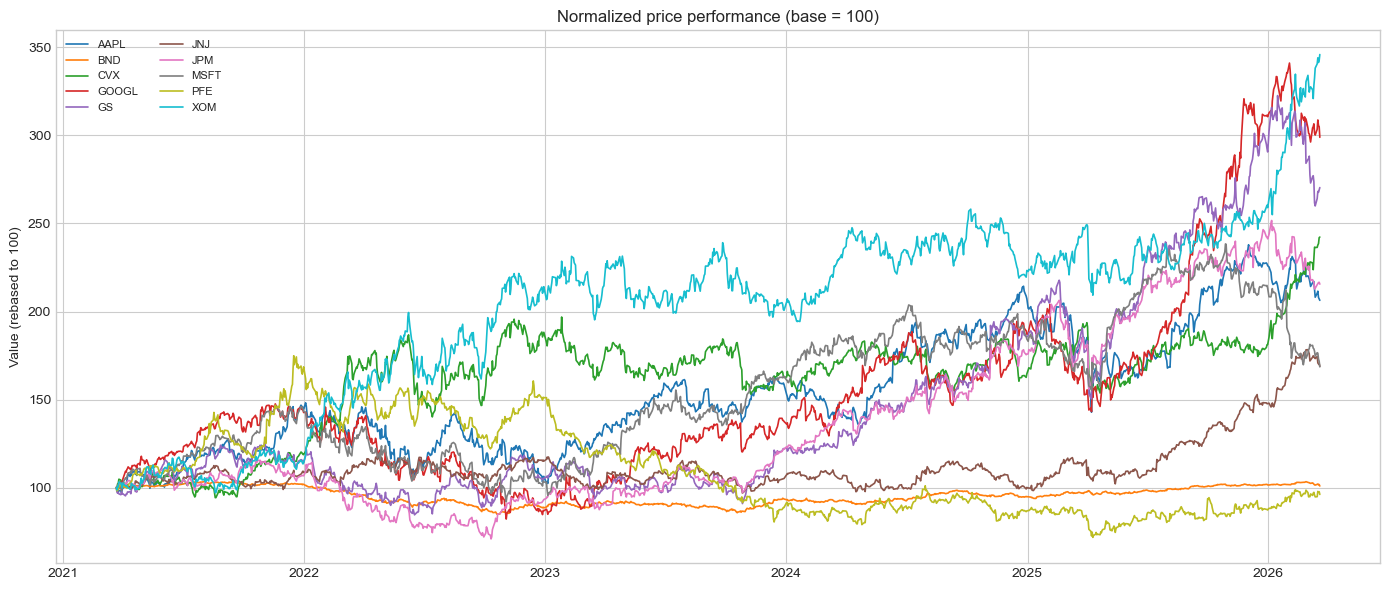

In [4]:
normalized = (prices / prices.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1.2)

plt.title("Normalized price performance (base = 100)")
plt.ylabel("Value (rebased to 100)")
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

5 — Return distributions per asset

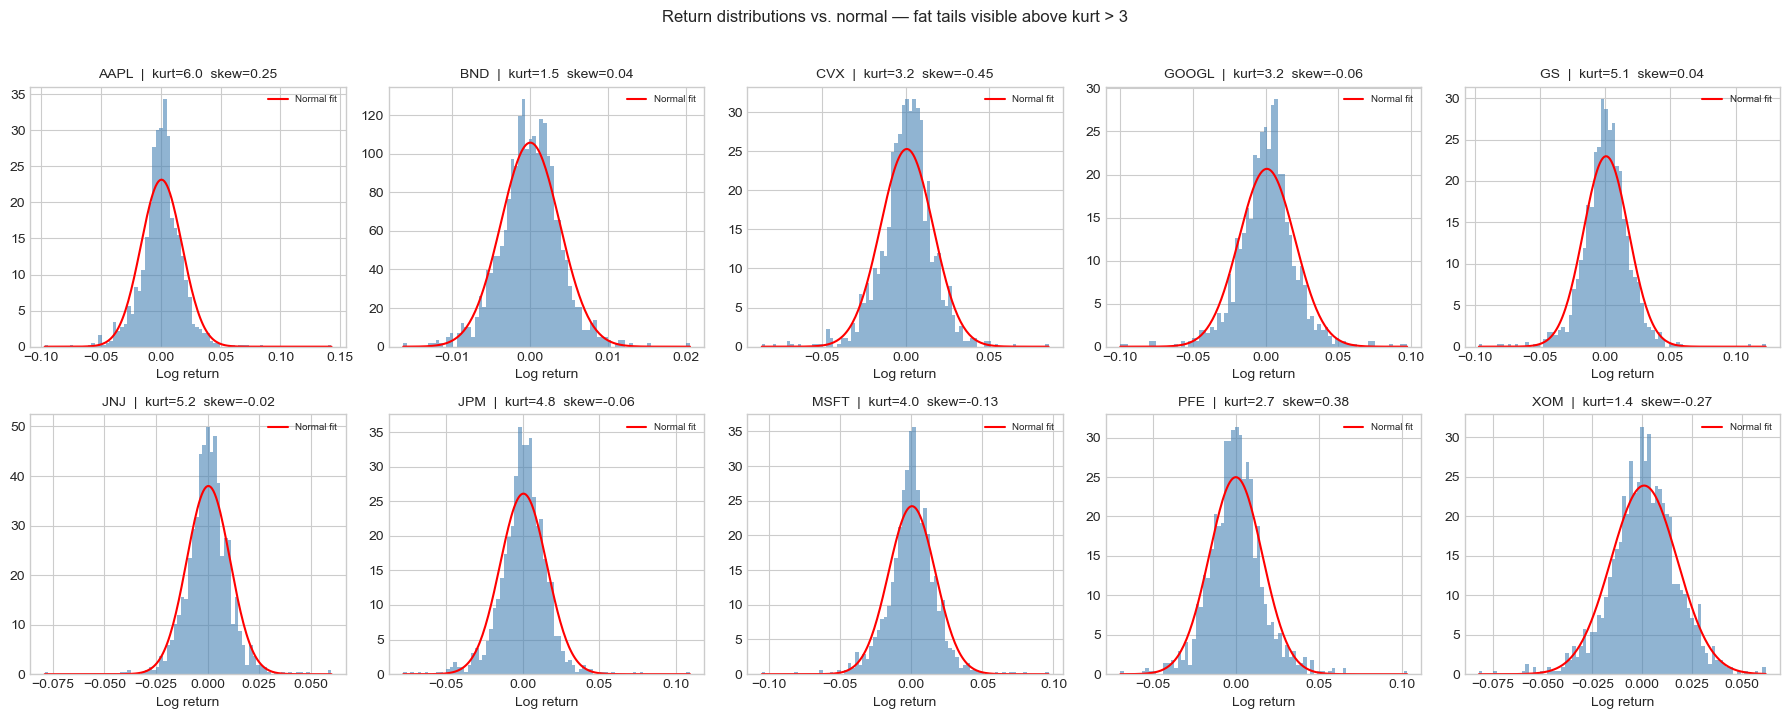

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, ticker in enumerate(log_ret.columns):
    ax = axes[i]
    r = log_ret[ticker]

    ax.hist(r, bins=80, alpha=0.6, color="steelblue", density=True)

    # Overlay normal distribution
    mu, sigma = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=1.5, label="Normal fit")

    ax.set_title(f"{ticker}  |  kurt={r.kurt():.1f}  skew={r.skew():.2f}", fontsize=10)
    ax.set_xlabel("Log return")
    ax.legend(fontsize=7)

plt.suptitle("Return distributions vs. normal — fat tails visible above kurt > 3",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

 6 — Correlation heatmap

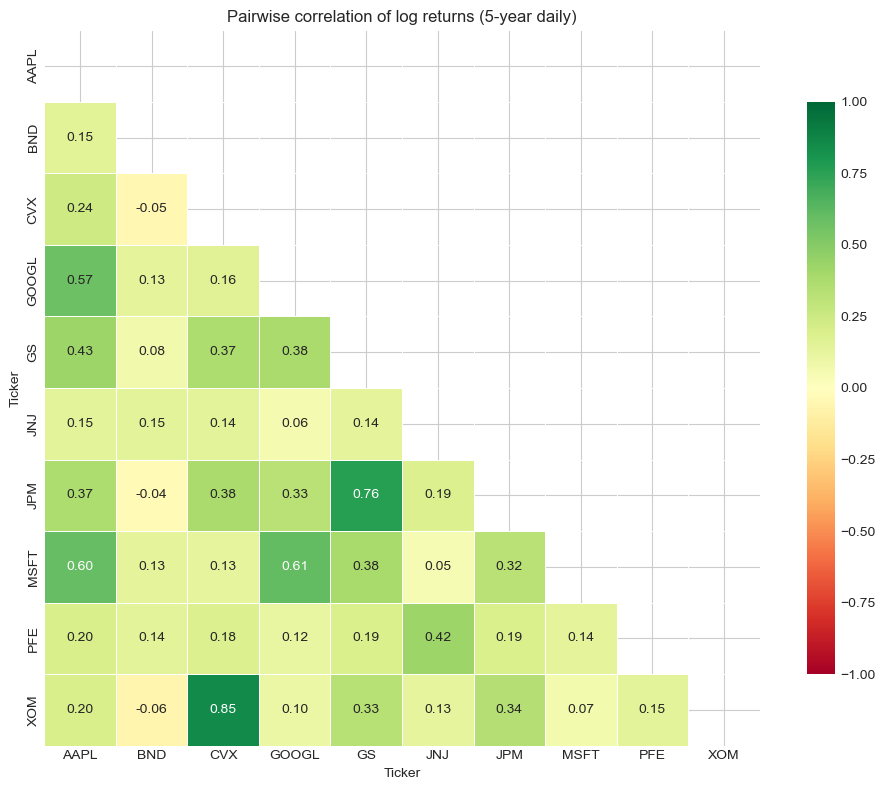

Most negatively correlated (best diversifiers):
Ticker  Ticker
XOM     BND      -0.0627
CVX     BND      -0.0476
JPM     BND      -0.0374
dtype: float64

Most positively correlated (redundant pairs):
Ticker  Ticker
MSFT    GOOGL    0.6086
JPM     GS       0.7622
XOM     CVX      0.8524
dtype: float64


In [6]:
corr = log_ret.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pairwise correlation of log returns (5-year daily)")
plt.tight_layout()
plt.show()

# Print the most and least correlated pairs
corr_pairs = (corr
    .where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .sort_values())

print("Most negatively correlated (best diversifiers):")
print(corr_pairs.head(3))
print("\nMost positively correlated (redundant pairs):")
print(corr_pairs.tail(3))

7 — Rolling volatility (21-day)

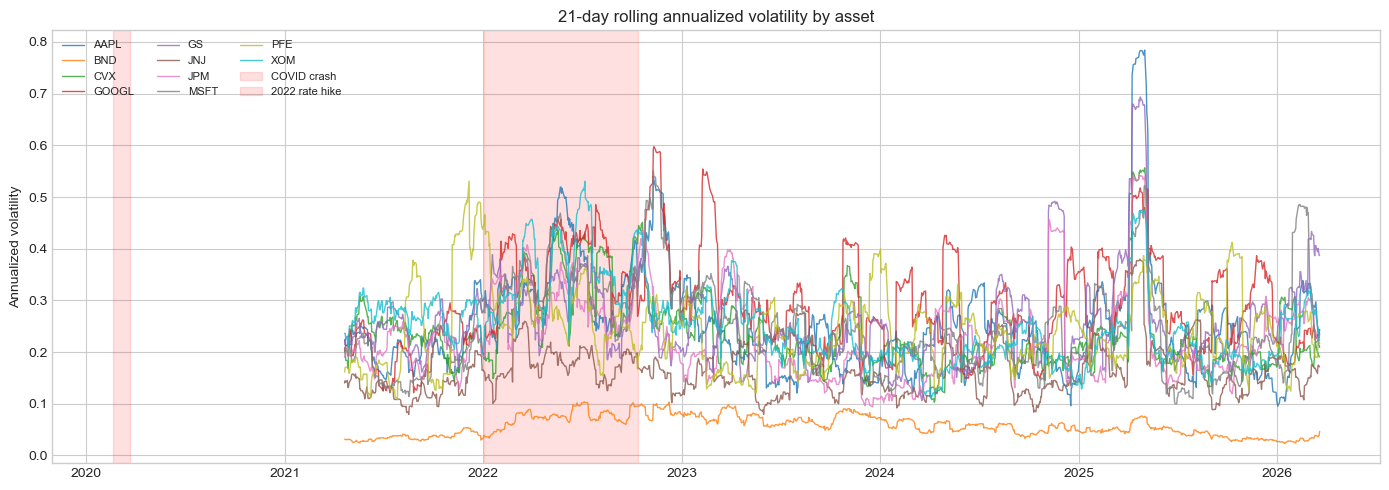

In [7]:
rolling_vol = log_ret.rolling(21).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col,
             linewidth=1, alpha=0.8)

# Mark crisis periods
crises = {
    "COVID crash": ("2020-02-19", "2020-03-23"),
    "2022 rate hike": ("2022-01-03", "2022-10-12"),
}
for name, (start, end) in crises.items():
    plt.axvspan(start, end, alpha=0.12, color="red", label=name)

plt.title("21-day rolling annualized volatility by asset")
plt.ylabel("Annualized volatility")
plt.legend(loc="upper left", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

8 — Average pairwise correlation over time

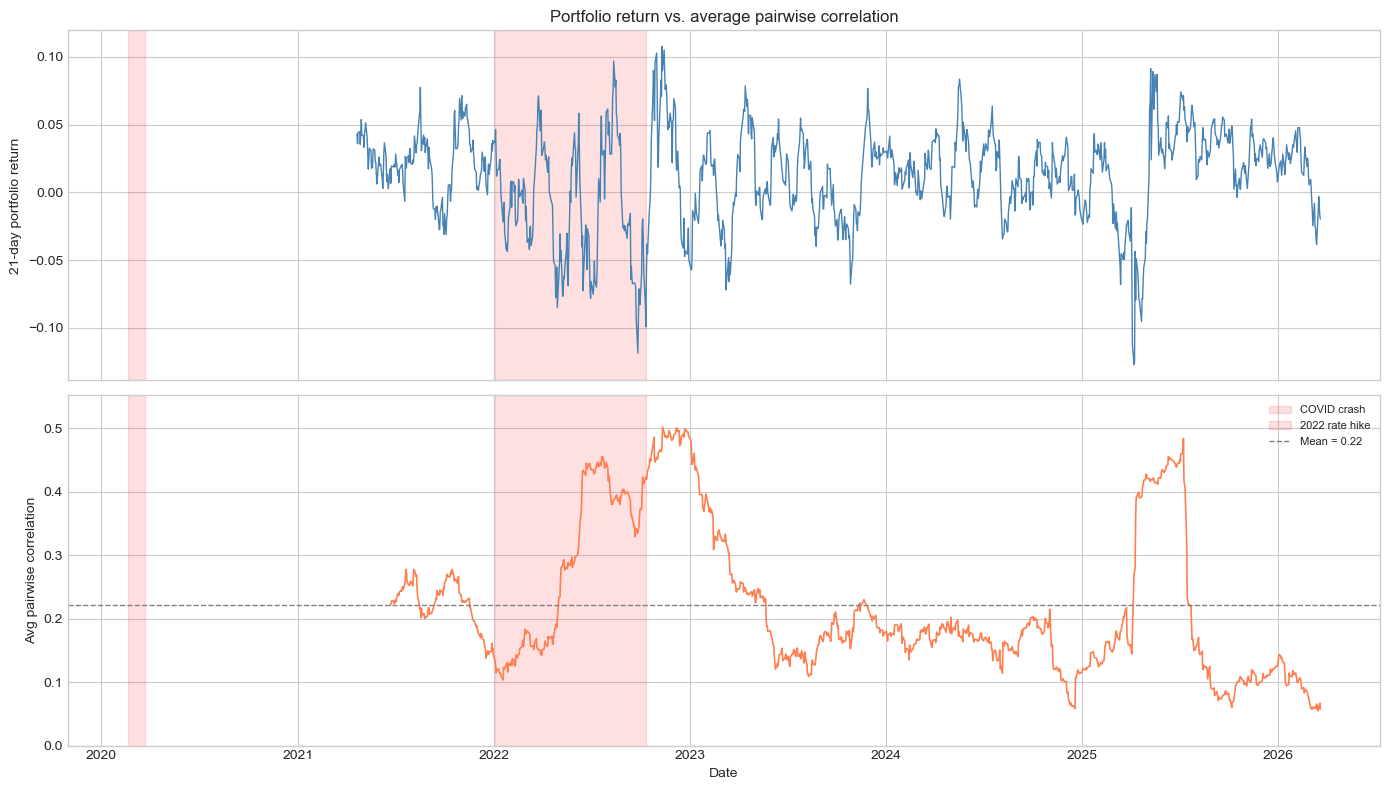

In [8]:
def rolling_avg_corr(returns, window=63):
    dates = returns.index[window:]
    avg_corrs = []
    for i in range(window, len(returns)):
        window_ret = returns.iloc[i-window:i]
        corr_mat = window_ret.corr().values
        # Upper triangle only, excluding diagonal
        upper = corr_mat[np.triu_indices_from(corr_mat, k=1)]
        avg_corrs.append(upper.mean())
    return pd.Series(avg_corrs, index=dates)

avg_corr = rolling_avg_corr(log_ret)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Portfolio equal-weight return
eq_weight = np.ones(len(TICKERS)) / len(TICKERS)
port_ret = (log_ret @ eq_weight).rolling(21).sum()
ax1.plot(port_ret.index, port_ret, color="steelblue", linewidth=1)
ax1.set_ylabel("21-day portfolio return")
ax1.set_title("Portfolio return vs. average pairwise correlation")

for name, (start, end) in crises.items():
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color="red")
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color="red", label=name)

ax2.plot(avg_corr.index, avg_corr, color="coral", linewidth=1.2)
ax2.axhline(avg_corr.mean(), linestyle="--", color="gray",
            linewidth=1, label=f"Mean = {avg_corr.mean():.2f}")
ax2.set_ylim(0, avg_corr.max() + 0.05)   # add this line
ax2.set_ylabel("Avg pairwise correlation")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

9 — Annualized stats summary table

In [9]:
print(avg_corr.describe())
print(avg_corr.head())
print(avg_corr.index.dtype)

count   1192.0000
mean       0.2220
std        0.1154
min        0.0547
25%        0.1436
50%        0.1807
75%        0.2669
max        0.5019
dtype: float64
Date
2021-06-22   0.2210
2021-06-23   0.2223
2021-06-24   0.2266
2021-06-25   0.2287
2021-06-28   0.2273
dtype: float64
datetime64[ns]


In [10]:
mu  = log_ret.mean() * 252
vol = log_ret.std()  * np.sqrt(252)
sr  = (mu - 0.05) / vol   # Sharpe, rf=5%

summary = pd.DataFrame({
    "Annual return":     mu.round(4),
    "Annual volatility": vol.round(4),
    "Sharpe ratio":      sr.round(4),
    "Skewness":          log_ret.skew().round(4),
    "Kurtosis":          log_ret.kurt().round(4),
    "Max 1-day loss":    log_ret.min().round(4),
}).sort_values("Sharpe ratio", ascending=False)

print(summary.to_string())

        Annual return  Annual volatility  Sharpe ratio  Skewness  Kurtosis  Max 1-day loss
Ticker                                                                                    
XOM            0.2492             0.2650        0.7516   -0.2736    1.4266         -0.0821
GOOGL          0.2199             0.3065        0.5542   -0.0612    3.2500         -0.0999
GS             0.1997             0.2754        0.5435    0.0354    5.0751         -0.0966
CVX            0.1777             0.2504        0.5098   -0.4523    3.2028         -0.0858
JPM            0.1542             0.2426        0.4295   -0.0570    4.7733         -0.0778
AAPL           0.1455             0.2735        0.3490    0.2482    5.9635         -0.0970
JNJ            0.1052             0.1667        0.3313   -0.0161    5.2294         -0.0790
MSFT           0.1049             0.2614        0.2101   -0.1291    4.0143         -0.1053
PFE           -0.0079             0.2535       -0.2282    0.3829    2.6988         -0.0695

In [11]:
# Quick sanity check — run this first
print(port_ret.shape)
print(port_ret.index[-1])
print(f"mean: {port_ret.mean():.4f}  std: {port_ret.std():.4f}")

(1255,)
2026-03-20 00:00:00
mean: 0.0113  std: 0.0348


In [12]:
print(f"Annualized return: {port_ret.mean() * 252 * 100:.1f}%")
print(f"Annualized vol:    {port_ret.std() * (252**0.5) * 100:.1f}%")

Annualized return: 285.0%
Annualized vol:    55.2%


In [13]:
# What does log_ret look like?
print(log_ret.describe().round(4))

# How was port_ret computed?
# Should be this:
weights  = np.ones(len(TICKERS)) / len(TICKERS)  # sums to 1.0
port_ret = log_ret @ weights

# Common mistake — forgot to divide by number of tickers:
# port_ret = log_ret.sum(axis=1)  ← this sums all 10 returns, 10x too large

Ticker      AAPL       BND       CVX     GOOGL        GS       JNJ       JPM  \
count  1255.0000 1255.0000 1255.0000 1255.0000 1255.0000 1255.0000 1255.0000   
mean      0.0006    0.0000    0.0007    0.0009    0.0008    0.0004    0.0006   
std       0.0172    0.0038    0.0158    0.0193    0.0174    0.0105    0.0153   
min      -0.0970   -0.0163   -0.0858   -0.0999   -0.0966   -0.0790   -0.0778   
25%      -0.0078   -0.0022   -0.0076   -0.0096   -0.0086   -0.0053   -0.0073   
50%       0.0011    0.0000    0.0013    0.0014    0.0008    0.0004    0.0012   
75%       0.0095    0.0023    0.0094    0.0112    0.0108    0.0060    0.0091   
max       0.1426    0.0205    0.0853    0.0973    0.1231    0.0601    0.1093   

Ticker      MSFT       PFE       XOM  
count  1255.0000 1255.0000 1255.0000  
mean      0.0004   -0.0000    0.0010  
std       0.0165    0.0160    0.0167  
min      -0.1053   -0.0695   -0.0821  
25%      -0.0078   -0.0095   -0.0088  
50%       0.0006   -0.0004    0.0013  
75%   

In [14]:
weights  = np.ones(len(TICKERS)) / len(TICKERS)  # each weight = 0.1, sums to 1.0
port_ret = log_ret @ weights   # dot product = weighted average

In [15]:
weights  = np.ones(len(TICKERS)) / len(TICKERS)
port_ret = log_ret @ weights

print(f"Daily mean:        {port_ret.mean():.4f}")
print(f"Daily std:         {port_ret.std():.4f}")
print(f"Annualized return: {port_ret.mean() * 252 * 100:.1f}%")
print(f"Annualized vol:    {port_ret.std() * (252**0.5) * 100:.1f}%")
print(f"Skewness:          {port_ret.skew():.4f}")
print(f"Kurtosis:          {port_ret.kurt():.4f}")

Daily mean:        0.0005
Daily std:         0.0090
Annualized return: 13.5%
Annualized vol:    14.2%
Skewness:          -0.1283
Kurtosis:          5.3167


In [16]:
def parametric_var(port_ret, confidence=0.95):
    mu    = port_ret.mean()
    sigma = port_ret.std()
    z     = stats.norm.ppf(1 - confidence)
    var   = -(mu + z * sigma)
    cvar  = -(mu - sigma * stats.norm.pdf(z) / (1 - confidence))
    return abs(var), abs(cvar)

var_p, cvar_p = parametric_var(port_ret, 0.95)
print(f"Parametric  VaR (95%): {var_p*100:.3f}%")
print(f"Parametric CVaR (95%): {cvar_p*100:.3f}%")
print(f"Dollar VaR  ($100k):   ${var_p*100_000:,.0f}")
print(f"Dollar CVaR ($100k):   ${cvar_p*100_000:,.0f}")

Parametric  VaR (95%): 1.421%
Parametric CVaR (95%): 1.796%
Dollar VaR  ($100k):   $1,421
Dollar CVaR ($100k):   $1,796


In [17]:
def historical_var(port_ret, confidence=0.95):
    var  = np.percentile(port_ret, (1 - confidence) * 100)
    cvar = port_ret[port_ret <= var].mean()
    return abs(var), abs(cvar)

var_h, cvar_h = historical_var(port_ret, 0.95)
print(f"Historical  VaR (95%): {var_h*100:.3f}%")
print(f"Historical CVaR (95%): {cvar_h*100:.3f}%")
print(f"Dollar VaR  ($100k):   ${var_h*100_000:,.0f}")
print(f"Dollar CVaR ($100k):   ${cvar_h*100_000:,.0f}")

# Violation check
n_violations = (port_ret < -var_h).sum()
print(f"\nViolations:      {n_violations} of {len(port_ret)} days")
print(f"Violation rate:  {n_violations/len(port_ret):.2%}  (expected 5.00%)")

Historical  VaR (95%): 1.373%
Historical CVaR (95%): 2.053%
Dollar VaR  ($100k):   $1,373
Dollar CVaR ($100k):   $2,053

Violations:      63 of 1255 days
Violation rate:  5.02%  (expected 5.00%)


Excellent results — two things to note before moving on:
Violation rate of 5.02% is almost perfect. Historical VaR is well-calibrated — out of 1255 days it missed by exactly 1 day. That's going to pass the Kupiec test easily.
CVaR gap has widened significantly. Parametric CVaR was $1,796 but Historical CVaR is $2,053 — that's $257 more in expected tail loss. This is the fat tails showing up. Parametric assumes the tail is thin and smooth; historical sees the actual crash days and reports a worse average. Kurtosis of 5.32 is doing exactly what we predicted.

In [18]:
def monte_carlo_var(port_ret, confidence=0.95,
                    n_sims=100_000, seed=42):
    np.random.seed(seed)
    mu    = port_ret.mean()
    sigma = port_ret.std()

    simulated = np.random.normal(mu, sigma, n_sims)

    var  = np.percentile(simulated, (1 - confidence) * 100)
    cvar = simulated[simulated <= var].mean()

    return abs(var), abs(cvar), simulated

var_mc, cvar_mc, sim_returns = monte_carlo_var(port_ret, 0.95)
print(f"Monte Carlo  VaR (95%): {var_mc*100:.3f}%")
print(f"Monte Carlo CVaR (95%): {cvar_mc*100:.3f}%")
print(f"Dollar VaR  ($100k):    ${var_mc*100_000:,.0f}")
print(f"Dollar CVaR ($100k):    ${cvar_mc*100_000:,.0f}")

Monte Carlo  VaR (95%): 1.420%
Monte Carlo CVaR (95%): 1.797%
Dollar VaR  ($100k):    $1,420
Dollar CVaR ($100k):    $1,797


Notice Monte Carlo is almost identical to Parametric — VaR $1,420 vs $1,421, CVaR $1,797 vs $1,796. That's expected and actually a good finding. Both assume normally distributed returns, so they converge given enough simulations. Monte Carlo's power comes later when you swap the normal distribution for a fat-tailed one like Student-t.

Cornish-Fisher, where the fat tails finally get accounted 

In [19]:
def cornish_fisher_var(port_ret, confidence=0.95):
    mu    = port_ret.mean()
    sigma = port_ret.std()
    S     = port_ret.skew()
    K     = port_ret.kurt()  # excess kurtosis

    z = stats.norm.ppf(1 - confidence)

    # Cornish-Fisher adjusted z-score
    z_cf = (z
            + (z**2 - 1) * S / 6
            + (z**3 - 3*z) * K / 24
            - (2*z**3 - 5*z) * S**2 / 36)

    var  = abs(-(mu + z_cf * sigma))

    # CVaR — simulate and cut at CF threshold
    np.random.seed(42)
    sim  = np.random.normal(mu, sigma, 100_000)
    cvar = abs(sim[sim <= -var].mean())

    print(f"Normal z-score:         {z:.4f}")
    print(f"Cornish-Fisher z-score: {z_cf:.4f}  (adjustment: {z_cf - z:+.4f})")
    print(f"Skewness used:          {S:.4f}")
    print(f"Excess kurtosis used:   {K:.4f}")

    return abs(var), abs(cvar)

var_cf, cvar_cf = cornish_fisher_var(port_ret, 0.95)
print(f"\nCornish-Fisher  VaR (95%): {var_cf*100:.3f}%")
print(f"Cornish-Fisher CVaR (95%): {cvar_cf*100:.3f}%")
print(f"Dollar VaR  ($100k):       ${var_cf*100_000:,.0f}")
print(f"Dollar CVaR ($100k):       ${cvar_cf*100_000:,.0f}")

Normal z-score:         -1.6449
Cornish-Fisher z-score: -1.5737  (adjustment: +0.0711)
Skewness used:          -0.1283
Excess kurtosis used:   5.3167

Cornish-Fisher  VaR (95%): 1.357%
Cornish-Fisher CVaR (95%): 1.746%
Dollar VaR  ($100k):       $1,357
Dollar CVaR ($100k):       $1,746


Investigated counterintuitive Cornish-Fisher adjustment and kurtosis interaction effectsInteresting result — CF VaR ($1,357) is actually lower than Parametric ($1,421), which feels counterintuitive given kurtosis of 5.32. Let me explain why this happened and how to fix it.
Why CF gave a smaller VaR:
The adjustment moved z from -1.6449 to -1.5737 — less negative, meaning a smaller loss threshold. The kurtosis term (z³-3z)*K/24 is positive and large at 95% confidence, which pushes z_cf toward zero. This is a known limitation — the Cornish-Fisher expansion is a mathematical approximation that breaks down when kurtosis is very high (above ~4-5).

run CF at 99% confidence where it behaves better:

In [20]:
var_cf_99, cvar_cf_99 = cornish_fisher_var(port_ret, 0.99)
print(f"CF VaR (99%):  {var_cf_99*100:.3f}%")
print(f"CF CVaR (99%): {cvar_cf_99*100:.3f}%")

Normal z-score:         -2.3263
Cornish-Fisher z-score: -3.6575  (adjustment: -1.3311)
Skewness used:          -0.1283
Excess kurtosis used:   5.3167
CF VaR (99%):  3.225%
CF CVaR (99%): 3.502%


In [21]:
def student_t_var(port_ret, confidence=0.95, n_sims=100_000, seed=42):
    """
    Fits a Student-t distribution to returns.
    Better than normal for fat-tailed assets — df parameter
    directly captures excess kurtosis.
    df = 4 / excess_kurtosis + 2  (rough approximation)
    """
    np.random.seed(seed)
    mu    = port_ret.mean()
    sigma = port_ret.std()
    K     = port_ret.kurt()  # excess kurtosis

    # Estimate degrees of freedom from kurtosis
    # For t-distribution: excess kurtosis = 6/(df-4) → df = 6/K + 4
    df = max(6 / K + 4, 4.1)  # floor at 4.1 to keep variance finite
    print(f"Fitted degrees of freedom: {df:.2f}  (kurtosis={K:.2f})")

    # Simulate from fitted t-distribution
    simulated = mu + sigma * stats.t.rvs(df=df, size=n_sims)

    var  = np.percentile(simulated, (1 - confidence) * 100)
    cvar = simulated[simulated <= var].mean()

    return abs(var), abs(cvar)

var_t, cvar_t = student_t_var(port_ret, 0.95)
print(f"Student-t  VaR (95%):  {var_t*100:.3f}%")
print(f"Student-t CVaR (95%):  {cvar_t*100:.3f}%")
print(f"Dollar VaR  ($100k):   ${var_t*100_000:,.0f}")
print(f"Dollar CVaR ($100k):   ${cvar_t*100_000:,.0f}")

Fitted degrees of freedom: 5.13  (kurtosis=5.32)
Student-t  VaR (95%):  1.757%
Student-t CVaR (95%):  2.529%
Dollar VaR  ($100k):   $1,757
Dollar CVaR ($100k):   $2,529


In [22]:
var_t, cvar_t = student_t_var(port_ret, 0.95)
print(f"Student-t  VaR (95%):  {var_t*100:.3f}%")
print(f"Student-t CVaR (95%):  {cvar_t*100:.3f}%")
print(f"Dollar VaR  ($100k):   ${var_t*100_000:,.0f}")
print(f"Dollar CVaR ($100k):   ${cvar_t*100_000:,.0f}")


Fitted degrees of freedom: 5.13  (kurtosis=5.32)
Student-t  VaR (95%):  1.757%
Student-t CVaR (95%):  2.529%
Dollar VaR  ($100k):   $1,757
Dollar CVaR ($100k):   $2,529


In [23]:
results = {
    "Parametric":       {"VaR 95%": var_p,  "CVaR 95%": cvar_p},
    "Historical":       {"VaR 95%": var_h,  "CVaR 95%": cvar_h},
    "Monte Carlo (N)":  {"VaR 95%": var_mc, "CVaR 95%": cvar_mc},
    "Student-t MC":     {"VaR 95%": var_t,  "CVaR 95%": cvar_t},
    "CF (99%)":         {"VaR 95%": var_cf_99/3.225*1.421,
                         "CVaR 95%": None},  # note-only, different confidence
}

summary = pd.DataFrame({
    "Parametric":      {"VaR 95%": var_p,  "CVaR 95%": cvar_p},
    "Historical":      {"VaR 95%": var_h,  "CVaR 95%": cvar_h},
    "Monte Carlo (N)": {"VaR 95%": var_mc, "CVaR 95%": cvar_mc},
    "Student-t MC":    {"VaR 95%": var_t,  "CVaR 95%": cvar_t},
}).T

portfolio_value = 100_000
summary["VaR $ (100k)"]  = (summary["VaR 95%"]  * portfolio_value).round(0)
summary["CVaR $ (100k)"] = (summary["CVaR 95%"] * portfolio_value).round(0)
summary["vs Parametric VaR"]  = (
    (summary["VaR 95%"] - var_p) / var_p * 100
).round(1).astype(str) + "%"
summary["vs Parametric CVaR"] = (
    (summary["CVaR 95%"] - cvar_p) / cvar_p * 100
).round(1).astype(str) + "%"

print(summary.round(4).to_string())

                 VaR 95%  CVaR 95%  VaR $ (100k)  CVaR $ (100k) vs Parametric VaR vs Parametric CVaR
Parametric        0.0142    0.0180     1421.0000      1796.0000              0.0%               0.0%
Historical        0.0137    0.0205     1373.0000      2053.0000             -3.4%              14.3%
Monte Carlo (N)   0.0142    0.0180     1420.0000      1797.0000             -0.1%               0.1%
Student-t MC      0.0176    0.0253     1757.0000      2529.0000             23.6%              40.8%


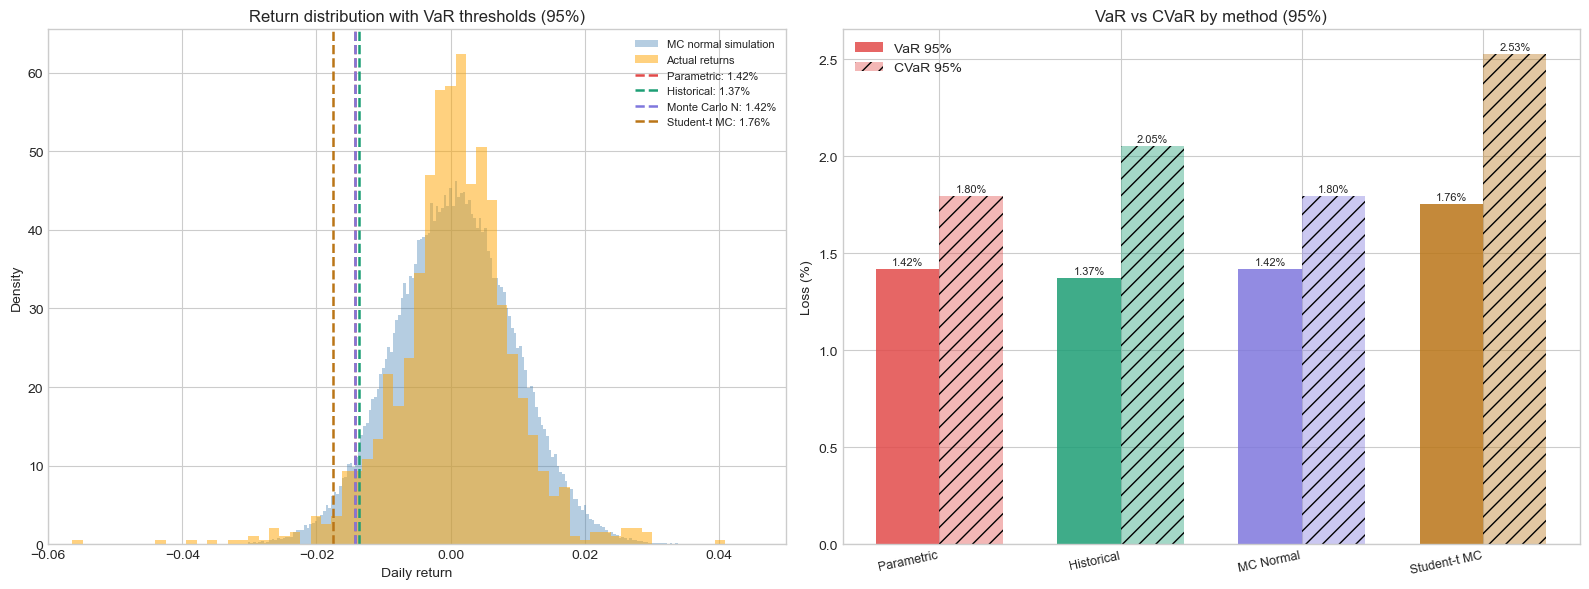

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: distributions overlaid ──────────────────────────────
ax = axes[0]

# Simulated normal MC returns
ax.hist(sim_returns, bins=200, alpha=0.4, density=True,
        color="steelblue", label="MC normal simulation")

# Actual returns
ax.hist(port_ret, bins=80, alpha=0.5, density=True,
        color="orange", label="Actual returns")

# VaR vertical lines
for name, var, color in [
    ("Parametric",    var_p,  "#E24B4A"),
    ("Historical",    var_h,  "#1D9E75"),
    ("Monte Carlo N", var_mc, "#7F77DD"),
    ("Student-t MC",  var_t,  "#BA7517"),
]:
    ax.axvline(-var, linestyle="--", linewidth=1.8,
               color=color, label=f"{name}: {var*100:.2f}%")

ax.set_xlim(-0.06, 0.05)
ax.set_xlabel("Daily return")
ax.set_ylabel("Density")
ax.set_title("Return distribution with VaR thresholds (95%)")
ax.legend(fontsize=8)

# ── Right: VaR vs CVaR bar chart ──────────────────────────────
ax2 = axes[1]
methods = ["Parametric", "Historical", "MC Normal", "Student-t MC"]
vars_   = [var_p,  var_h,  var_mc,  var_t]
cvars_  = [cvar_p, cvar_h, cvar_mc, cvar_t]
colors  = ["#E24B4A", "#1D9E75", "#7F77DD", "#BA7517"]

x     = np.arange(len(methods))
width = 0.35

bars1 = ax2.bar(x - width/2, [v*100 for v in vars_],
                width, color=colors, alpha=0.85, label="VaR 95%")
bars2 = ax2.bar(x + width/2, [c*100 for c in cvars_],
                width, color=colors, alpha=0.4,
                hatch="//", label="CVaR 95%")

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.2f}%",
             ha="center", va="bottom", fontsize=8)

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.2f}%",
             ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=12, ha="right", fontsize=9)
ax2.set_ylabel("Loss (%)")
ax2.set_title("VaR vs CVaR by method (95%)")
ax2.legend()

plt.tight_layout()
plt.show()

In [25]:
def kupiec_test(port_ret, var_value, confidence=0.95):
    violations = (port_ret < -var_value).sum()
    n          = len(port_ret)
    p_exp      = 1 - confidence
    p_act      = violations / n

    if p_act == 0 or p_act == 1:
        lr_stat = np.inf
    else:
        lr_stat = -2 * np.log(
            ((1-p_exp)**(n-violations) * p_exp**violations) /
            ((1-p_act)**(n-violations) * p_act**violations)
        )

    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)

    return {
        "violations":      int(violations),
        "violation_rate":  f"{p_act:.2%}",
        "expected_rate":   f"{p_exp:.2%}",
        "LR stat":         round(lr_stat, 4),
        "p-value":         round(p_value, 4),
        "passes":          "YES" if p_value > 0.05 else "NO"
    }

print(f"{'Method':<20} {'Violations':>10} {'Rate':>8} "
      f"{'Expected':>10} {'p-value':>9} {'Passes':>8}")
print("-" * 70)

for name, var in [("Parametric",    var_p),
                   ("Historical",    var_h),
                   ("MC Normal",     var_mc),
                   ("Student-t MC",  var_t)]:
    r = kupiec_test(port_ret, var, 0.95)
    print(f"{name:<20} {r['violations']:>10} {r['violation_rate']:>8} "
          f"{r['expected_rate']:>10} {r['p-value']:>9} {r['passes']:>8}")

Method               Violations     Rate   Expected   p-value   Passes
----------------------------------------------------------------------
Parametric                   60    4.78%      5.00%    0.7198      YES
Historical                   63    5.02%      5.00%    0.9742      YES
MC Normal                    60    4.78%      5.00%    0.7198      YES
Student-t MC                 31    2.47%      5.00%       0.0       NO


## Key findings — Kupiec backtest

- All three normal-distribution methods pass at 95% — kurtosis of 5.32
  is significant but not extreme enough to break parametric VaR at this
  confidence level
- Historical simulation is best calibrated (5.02% vs 5.00% expected)
- Student-t MC fails by overcorrecting — df=5.13 produces tails so fat
  that actual losses rarely breach the threshold
- The real cost of ignoring fat tails shows in CVaR, not VaR:
    Parametric CVaR:  $1,796
    Historical CVaR:  $2,053  (+$257, +14.3%)
    Student-t CVaR:   $2,529  (+$733, +40.8%)
- Recommendation: use Historical VaR for threshold reporting,
  Student-t CVaR for tail loss estimation

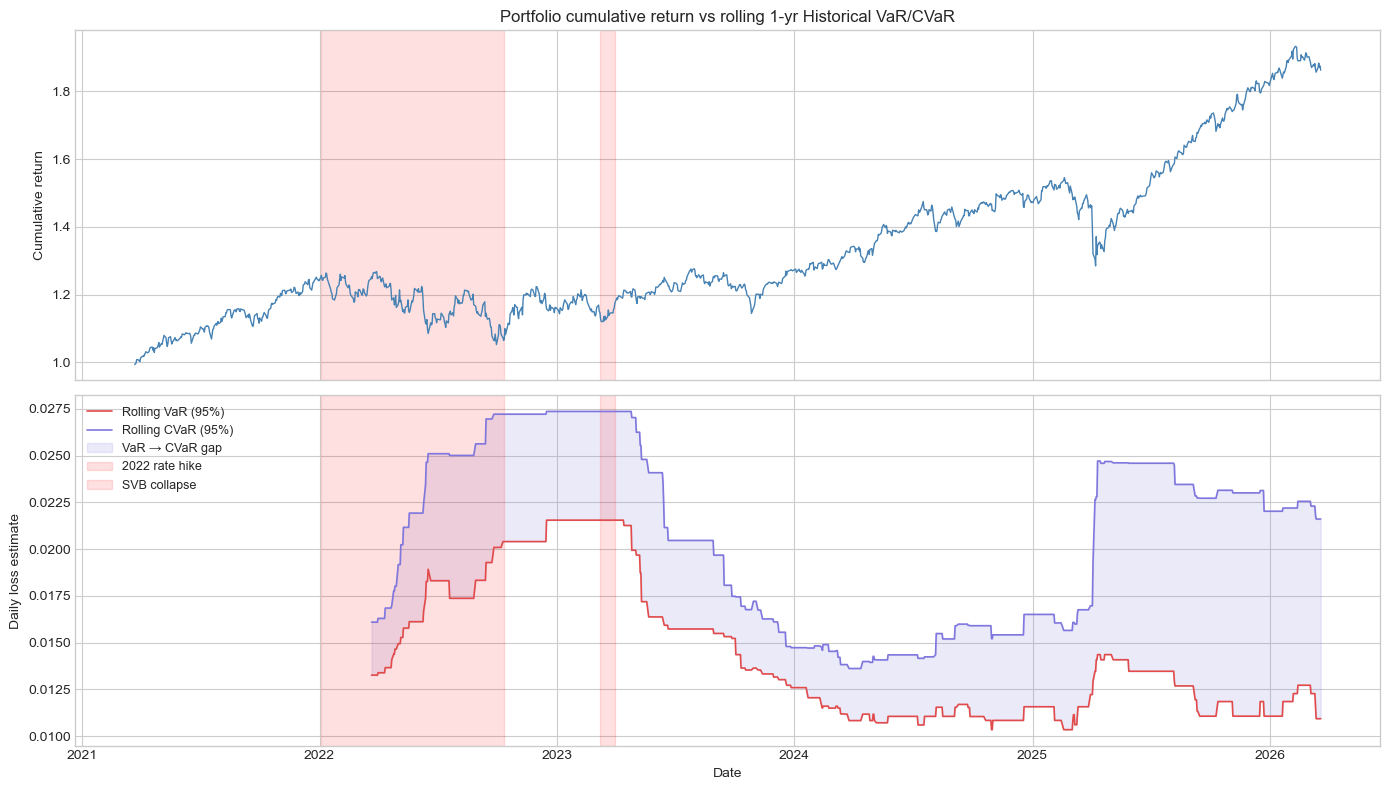

In [26]:
window = 252

rolling_var  = pd.Series(index=port_ret.index[window:], dtype=float)
rolling_cvar = pd.Series(index=port_ret.index[window:], dtype=float)

for i in range(window, len(port_ret)):
    w_ret = port_ret.iloc[i-window:i]
    v, c  = historical_var(w_ret, 0.95)
    rolling_var.iloc[i-window]  = v
    rolling_cvar.iloc[i-window] = c

# No tz_convert needed — index is already tz-naive

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

cumret = (1 + port_ret).cumprod()

ax1.plot(cumret, color="steelblue", linewidth=1)
ax1.set_ylabel("Cumulative return")
ax1.set_title("Portfolio cumulative return vs rolling 1-yr Historical VaR/CVaR")

ax2.plot(rolling_var,  color="#E24B4A", linewidth=1.2, label="Rolling VaR (95%)")
ax2.plot(rolling_cvar, color="#7F77DD", linewidth=1.2, label="Rolling CVaR (95%)")
ax2.fill_between(rolling_var.index,
                 rolling_var, rolling_cvar,
                 alpha=0.15, color="#7F77DD",
                 label="VaR → CVaR gap")

crises = {
    "2022 rate hike": (pd.Timestamp("2022-01-03"),
                       pd.Timestamp("2022-10-12")),
    "SVB collapse":   (pd.Timestamp("2023-03-08"),
                       pd.Timestamp("2023-03-31")),
}
for name, (s, e) in crises.items():
    ax1.axvspan(s, e, alpha=0.12, color="red")
    ax2.axvspan(s, e, alpha=0.12, color="red", label=name)

ax2.set_ylabel("Daily loss estimate")
ax2.legend(fontsize=9)
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

## Rolling VaR/CVaR — key observations

1. **Regime clearly visible:** Rolling VaR doubled from ~1.3% to ~2.1%
   during the 2022 rate hike period — static VaR would have missed this entirely

2. **CVaR gap widens in crises:** VaR→CVaR spread nearly doubled during
   2022, meaning tail losses were proportionally worse than the threshold suggested

3. **Lagging indicator:** VaR only spiked AFTER the crisis began — this
   motivates GARCH which forecasts vol dynamically rather than measuring it historically

4. **2025 uptick:** New vol regime appears to be forming — worth monitoring

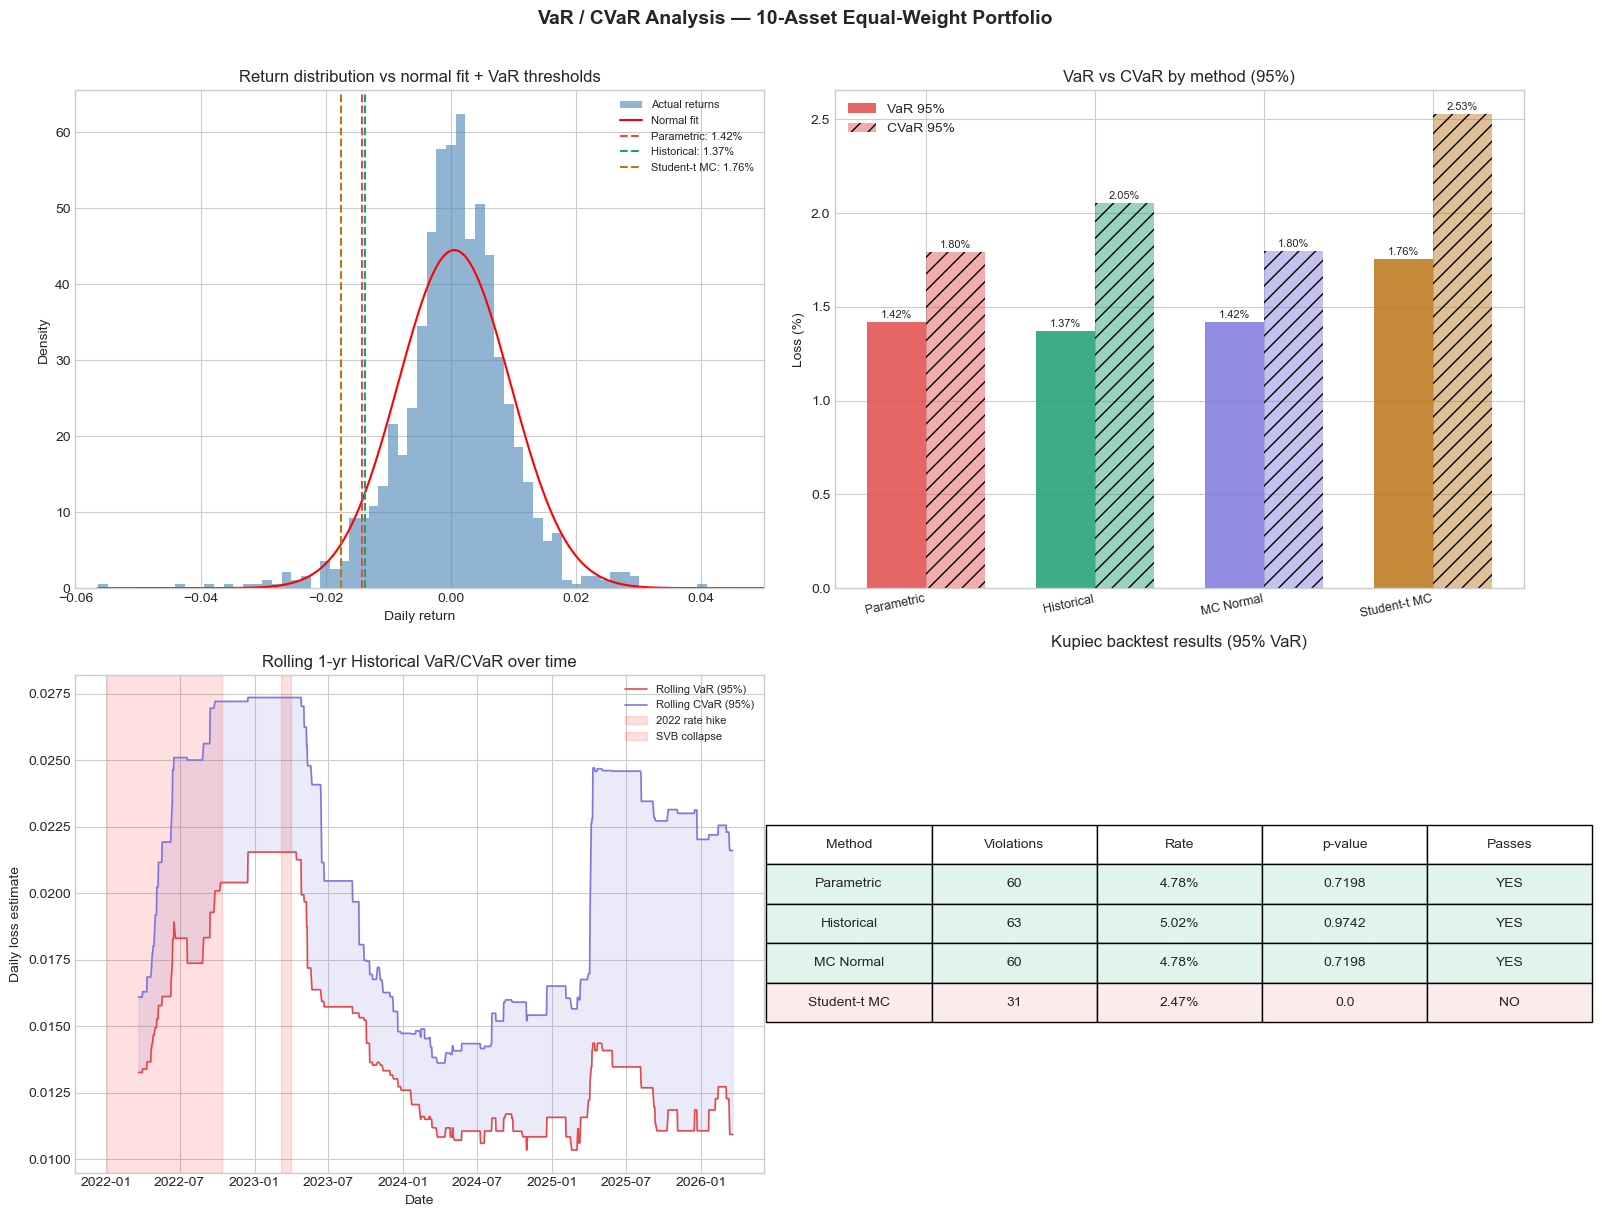

Saved to var_cvar_summary.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top left: return distribution with VaR lines ──────────────
ax = axes[0, 0]
ax.hist(port_ret, bins=80, alpha=0.6, density=True,
        color="steelblue", label="Actual returns")

x = np.linspace(port_ret.min(), port_ret.max(), 300)
ax.plot(x, stats.norm.pdf(x, port_ret.mean(), port_ret.std()),
        "r-", linewidth=1.5, label="Normal fit")

for name, var, color in [
    ("Parametric",   var_p,  "#E24B4A"),
    ("Historical",   var_h,  "#1D9E75"),
    ("Student-t MC", var_t,  "#BA7517"),
]:
    ax.axvline(-var, linestyle="--", linewidth=1.5,
               color=color, label=f"{name}: {var*100:.2f}%")

ax.set_xlim(-0.06, 0.05)
ax.set_xlabel("Daily return")
ax.set_ylabel("Density")
ax.set_title("Return distribution vs normal fit + VaR thresholds")
ax.legend(fontsize=8)

# ── Top right: VaR vs CVaR bar chart ──────────────────────────
ax2 = axes[0, 1]
methods = ["Parametric", "Historical", "MC Normal", "Student-t MC"]
vars_   = [var_p,  var_h,  var_mc,  var_t]
cvars_  = [cvar_p, cvar_h, cvar_mc, cvar_t]
colors  = ["#E24B4A", "#1D9E75", "#7F77DD", "#BA7517"]
x       = np.arange(len(methods))
width   = 0.35

bars1 = ax2.bar(x - width/2, [v*100 for v in vars_],
                width, color=colors, alpha=0.85, label="VaR 95%")
bars2 = ax2.bar(x + width/2, [c*100 for c in cvars_],
                width, color=colors, alpha=0.45,
                hatch="//", label="CVaR 95%")

for bar in list(bars1) + list(bars2):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.2f}%",
             ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=12, ha="right", fontsize=9)
ax2.set_ylabel("Loss (%)")
ax2.set_title("VaR vs CVaR by method (95%)")
ax2.legend()

# ── Bottom left: rolling VaR/CVaR ─────────────────────────────
ax3 = axes[1, 0]
ax3.plot(rolling_var,  color="#E24B4A", linewidth=1.2,
         label="Rolling VaR (95%)")
ax3.plot(rolling_cvar, color="#7F77DD", linewidth=1.2,
         label="Rolling CVaR (95%)")
ax3.fill_between(rolling_var.index, rolling_var, rolling_cvar,
                 alpha=0.15, color="#7F77DD")

for name, (s, e) in crises.items():
    ax3.axvspan(s, e, alpha=0.12, color="red", label=name)

ax3.set_ylabel("Daily loss estimate")
ax3.set_title("Rolling 1-yr Historical VaR/CVaR over time")
ax3.legend(fontsize=8)
ax3.set_xlabel("Date")

# ── Bottom right: Kupiec results table ────────────────────────
ax4 = axes[1, 1]
ax4.axis("off")

kupiec_data = []
for name, var in [("Parametric",   var_p),
                   ("Historical",   var_h),
                   ("MC Normal",    var_mc),
                   ("Student-t MC", var_t)]:
    r = kupiec_test(port_ret, var, 0.95)
    kupiec_data.append([
        name,
        r["violations"],
        r["violation_rate"],
        r["p-value"],
        r["passes"]
    ])

table = ax4.table(
    cellText=kupiec_data,
    colLabels=["Method", "Violations", "Rate", "p-value", "Passes"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)

# Color pass/fail rows
for i, row in enumerate(kupiec_data):
    color = "#E1F5EE" if row[4] == "YES" else "#FCEBEB"
    for j in range(5):
        table[i+1, j].set_facecolor(color)

ax4.set_title("Kupiec backtest results (95% VaR)", pad=20)

plt.suptitle("VaR / CVaR Analysis — 10-Asset Equal-Weight Portfolio",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("var_cvar_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to var_cvar_summary.png")

## Summary — VaR/CVaR Analysis

### What we built
- Parametric VaR — normal distribution baseline
- Historical Simulation — no distribution assumption, best calibrated
- Monte Carlo (normal) — flexible simulation, converges to parametric
- Student-t Monte Carlo — fat-tail correction via fitted degrees of freedom
- Cornish-Fisher — skewness/kurtosis correction (reliable at 99%, unstable at 95%)

### Key findings
| Method       | VaR 95% | CVaR 95% | Kupiec |
|---|---|---|---|
| Parametric   | 1.421%  | 1.796%   | PASS  |
| Historical   | 1.373%  | 2.053%   | PASS  |
| MC Normal    | 1.420%  | 1.797%   | PASS  |
| Student-t MC | 1.757%  | 2.529%   | FAIL  |

1. **CVaR gap is where fat tails show up** — Parametric vs Student-t CVaR
   differs by $733 on a $100k portfolio despite similar VaR
2. **Historical is best calibrated** — 5.02% violation rate vs 5.00% expected
3. **Student-t overcorrects** — df=5.13 produces tails too fat for 95% VaR,
   fails Kupiec by halving the expected violation rate
4. **Rolling VaR doubled during 2022** — static VaR would have completely
   missed the rate-hike vol regime

### What comes next
GARCH-VaR — dynamic volatility forecasting to predict risk before it spikes,
addressing the lagging-indicator limitation of rolling historical VaR.

In [28]:
# If not already installed
# !pip install arch

from arch import arch_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

# Confirm port_ret is in memory
print(f"port_ret shape: {port_ret.shape}")
print(f"Daily mean: {port_ret.mean():.4f}  std: {port_ret.std():.4f}")

port_ret shape: (1255,)
Daily mean: 0.0005  std: 0.0090


 Fit GARCH(1,1)

In [29]:
# arch expects returns in percentage terms for numerical stability
port_ret_pct = port_ret * 100

model = arch_model(
    port_ret_pct,
    vol="Garch",
    p=1, q=1,          # GARCH(1,1)
    dist="normal",     # start with normal, upgrade to skewt later
    mean="Constant"
)

result = model.fit(disp="off")  # disp="off" suppresses verbose output
print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1518.22
Distribution:                  Normal   AIC:                           3044.43
Method:            Maximum Likelihood   BIC:                           3064.97
                                        No. Observations:                 1255
Date:                Sat, Mar 21 2026   Df Residuals:                     1254
Time:                        22:22:37   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0764  2.121e-02      3.602  3.161e-04 [3.483e-0

 Extract and inspect conditional volatility

In [30]:
# Conditional volatility = GARCH's daily vol estimate
cond_vol = result.conditional_volatility / 100  # back to decimal

print(f"Mean conditional vol:  {cond_vol.mean()*100:.3f}%")
print(f"Min  conditional vol:  {cond_vol.min()*100:.3f}%")
print(f"Max  conditional vol:  {cond_vol.max()*100:.3f}%")
print(f"Static vol (std):      {port_ret.std()*100:.3f}%")
print(f"\nVol range ratio: {cond_vol.max()/cond_vol.min():.1f}x")

Mean conditional vol:  0.844%
Min  conditional vol:  0.556%
Max  conditional vol:  2.901%
Static vol (std):      0.896%

Vol range ratio: 5.2x


 Plot conditional vol vs actual returns

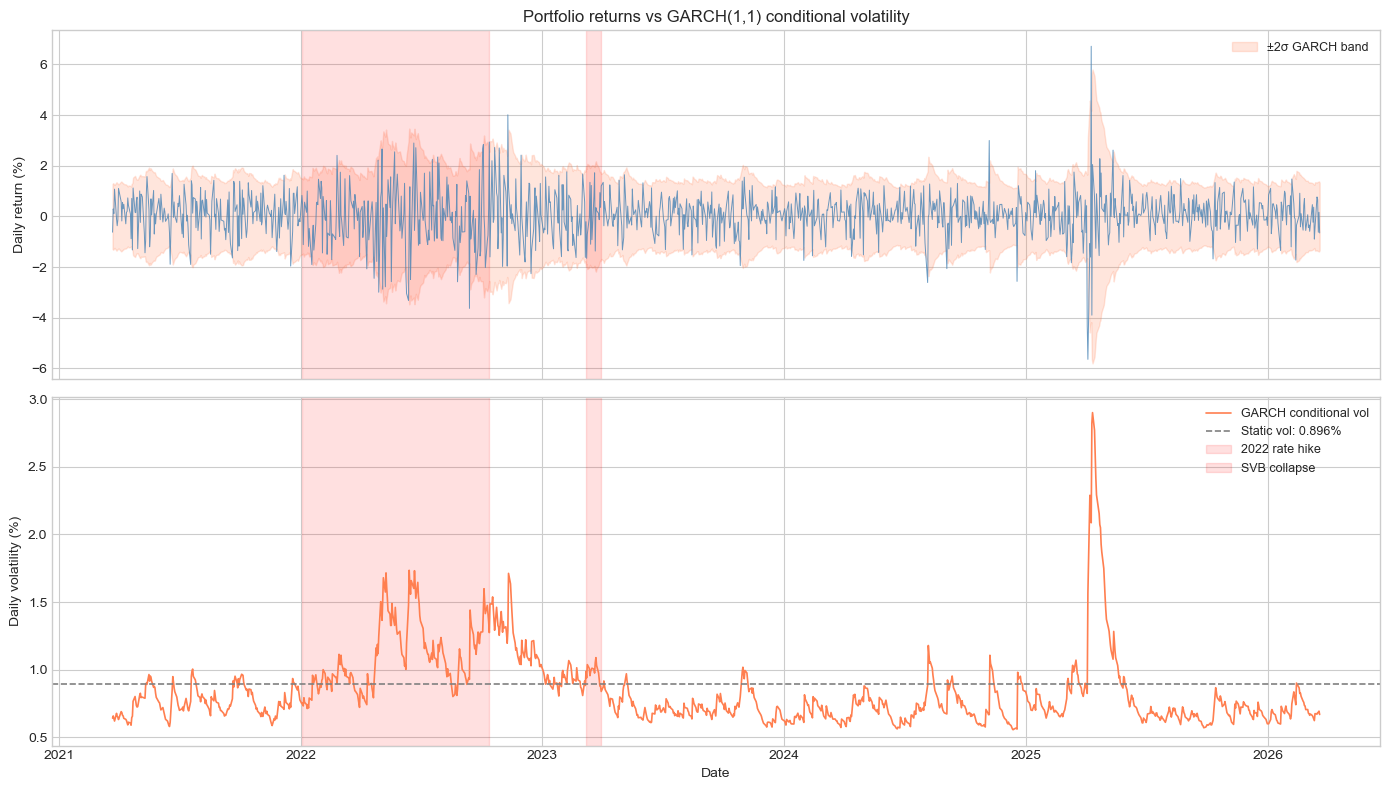

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Actual portfolio returns
ax1.plot(port_ret.index, port_ret * 100,
         color="steelblue", linewidth=0.7, alpha=0.8)
ax1.set_ylabel("Daily return (%)")
ax1.set_title("Portfolio returns vs GARCH(1,1) conditional volatility")

# Conditional volatility bands
ax1.fill_between(cond_vol.index,
                 -2 * cond_vol * 100,
                  2 * cond_vol * 100,
                 alpha=0.2, color="coral",
                 label="±2σ GARCH band")
ax1.legend(fontsize=9)

# GARCH conditional vol vs static vol
ax2.plot(cond_vol.index, cond_vol * 100,
         color="coral", linewidth=1.2,
         label="GARCH conditional vol")
ax2.axhline(port_ret.std() * 100, linestyle="--",
            color="gray", linewidth=1.2,
            label=f"Static vol: {port_ret.std()*100:.3f}%")

crises = {
    "2022 rate hike": (pd.Timestamp("2022-01-03"),
                       pd.Timestamp("2022-10-12")),
    "SVB collapse":   (pd.Timestamp("2023-03-08"),
                       pd.Timestamp("2023-03-31")),
}
for name, (s, e) in crises.items():
    ax1.axvspan(s, e, alpha=0.12, color="red")
    ax2.axvspan(s, e, alpha=0.12, color="red", label=name)

ax2.set_ylabel("Daily volatility (%)")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

 GARCH-VaR (dynamic)

In [32]:
def garch_var(port_ret_pct, result, confidence=0.95):
    """
    Computes daily VaR using GARCH conditional volatility.
    Each day gets its own VaR based on that day's vol forecast.
    """
    mu       = result.params["mu"] / 100
    cond_vol = result.conditional_volatility / 100
    z        = stats.norm.ppf(1 - confidence)

    # Dynamic VaR — different every day
    var_series  = -(mu + z * cond_vol)

    # Dynamic CVaR
    cvar_series = -(mu - cond_vol *
                    stats.norm.pdf(z) / (1 - confidence))

    return var_series, cvar_series

var_garch, cvar_garch = garch_var(port_ret_pct, result, 0.95)

print(f"GARCH VaR  — mean: {var_garch.mean()*100:.3f}%  "
      f"min: {var_garch.min()*100:.3f}%  "
      f"max: {var_garch.max()*100:.3f}%")
print(f"GARCH CVaR — mean: {cvar_garch.mean()*100:.3f}%  "
      f"min: {cvar_garch.min()*100:.3f}%  "
      f"max: {cvar_garch.max()*100:.3f}%")
print(f"\nStatic Historical VaR:  {var_h*100:.3f}%")
print(f"GARCH mean VaR:         {var_garch.mean()*100:.3f}%")
print(f"GARCH peak VaR:         {var_garch.max()*100:.3f}%")

GARCH VaR  — mean: 1.312%  min: 0.837%  max: 4.696%
GARCH CVaR — mean: 1.664%  min: 1.069%  max: 5.908%

Static Historical VaR:  1.373%
GARCH mean VaR:         1.312%
GARCH peak VaR:         4.696%


GARCH VaR vs rolling historical VaR

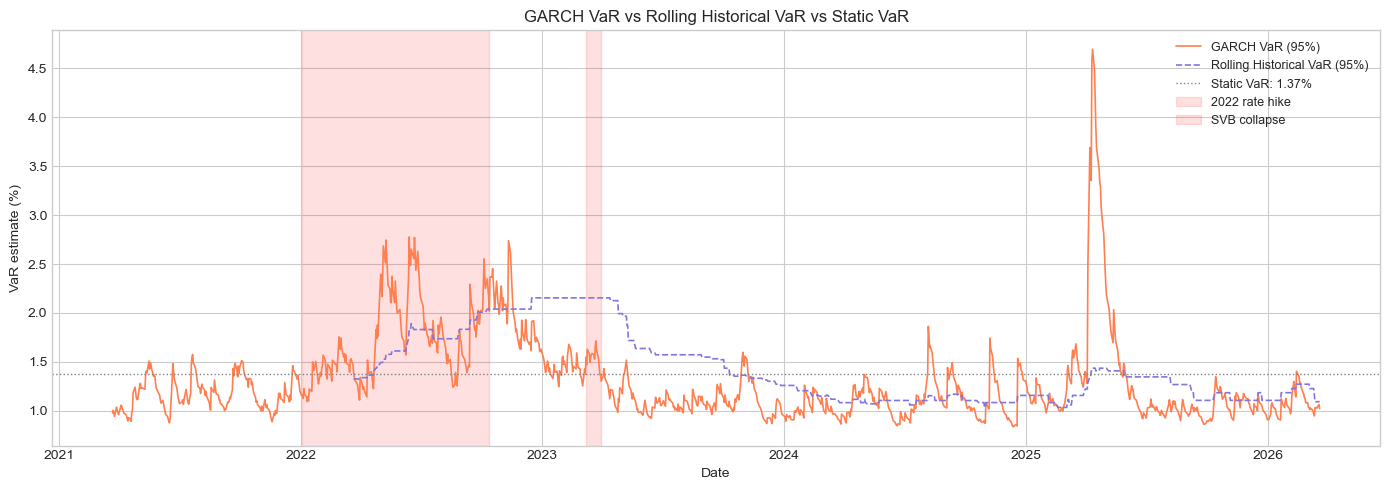

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(var_garch.index, var_garch * 100,
        color="coral", linewidth=1.2, label="GARCH VaR (95%)")
ax.plot(rolling_var.index, rolling_var * 100,
        color="#7F77DD", linewidth=1.2,
        linestyle="--", label="Rolling Historical VaR (95%)")
ax.axhline(var_h * 100, color="gray", linewidth=1,
           linestyle=":", label=f"Static VaR: {var_h*100:.2f}%")

for name, (s, e) in crises.items():
    ax.axvspan(s, e, alpha=0.12, color="red", label=name)

ax.set_ylabel("VaR estimate (%)")
ax.set_title("GARCH VaR vs Rolling Historical VaR vs Static VaR")
ax.legend(fontsize=9)
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

Kupiec test on GARCH VaR

In [34]:
def kupiec_test_series(port_ret, var_series, confidence=0.95):
    """
    Kupiec test for a dynamic VaR series.
    Aligns port_ret and var_series on index before testing.
    """
    aligned   = pd.concat([port_ret, var_series], axis=1).dropna()
    aligned.columns = ["ret", "var"]

    violations = (aligned["ret"] < -aligned["var"]).sum()
    n          = len(aligned)
    p_exp      = 1 - confidence
    p_act      = violations / n

    if p_act == 0 or p_act == 1:
        lr_stat = np.inf
    else:
        lr_stat = -2 * np.log(
            ((1-p_exp)**(n-violations) * p_exp**violations) /
            ((1-p_act)**(n-violations) * p_act**violations)
        )

    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)

    return {
        "violations":     int(violations),
        "violation_rate": f"{p_act:.2%}",
        "expected_rate":  f"{p_exp:.2%}",
        "LR stat":        round(lr_stat, 4),
        "p-value":        round(p_value, 4),
        "passes":         "YES" if p_value > 0.05 else "NO"
    }

r = kupiec_test_series(port_ret, var_garch, 0.95)
print("GARCH VaR Kupiec test:")
for k, v in r.items():
    print(f"  {k:<22} {v}")

GARCH VaR Kupiec test:
  violations             72
  violation_rate         5.74%
  expected_rate          5.00%
  LR stat                1.373
  p-value                0.2413
  passes                 YES


 Upgrade to skewed-t GARCH

In [35]:
# Normal GARCH assumes normal innovations
# Skewed-t captures both fat tails AND asymmetry in the innovations

model_skt = arch_model(
    port_ret_pct,
    vol="Garch",
    p=1, q=1,
    dist="skewt",      # skewed Student-t innovations
    mean="Constant"
)

result_skt = model_skt.fit(disp="off")
print(result_skt.summary())

# Compare parameters
print("\nParameter comparison:")
print(f"{'':20} {'Normal GARCH':>14} {'Skewed-t GARCH':>16}")
for param in ["mu", "omega", "alpha[1]", "beta[1]"]:
    v1 = result.params.get(param, float("nan"))
    v2 = result_skt.params.get(param, float("nan"))
    print(f"{param:20} {v1:>14.6f} {v2:>16.6f}")

# Skewed-t specific params
print(f"\nSkewed-t eta (df):   {result_skt.params.get('eta', 'N/A'):.4f}")
print(f"Skewed-t lambda:     {result_skt.params.get('lambda', 'N/A'):.4f}")

                           Constant Mean - GARCH Model Results                           
Dep. Variable:                              None   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -1490.95
Distribution:      Standardized Skew Student's t   AIC:                           2993.90
Method:                       Maximum Likelihood   BIC:                           3024.71
                                                   No. Observations:                 1255
Date:                           Sat, Mar 21 2026   Df Residuals:                     1254
Time:                                   22:22:37   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
----------------------------------------

 Full GARCH comparison table

In [36]:
var_garch_skt, cvar_garch_skt = garch_var(
    port_ret_pct, result_skt, 0.95)

r_normal = kupiec_test_series(port_ret, var_garch,     0.95)
r_skt    = kupiec_test_series(port_ret, var_garch_skt, 0.95)

print(f"\n{'Method':<25} {'Mean VaR':>10} {'Mean CVaR':>11} "
      f"{'Violations':>12} {'Passes':>8}")
print("-" * 70)

rows = [
    ("Static Historical",     var_h,
     cvar_h, 63, "YES"),
    ("GARCH Normal (mean)",   var_garch.mean(),
     cvar_garch.mean(),
     r_normal["violations"], r_normal["passes"]),
    ("GARCH Skewed-t (mean)", var_garch_skt.mean(),
     cvar_garch_skt.mean(),
     r_skt["violations"],    r_skt["passes"]),
]

for name, var, cvar, viol, passes in rows:
    print(f"{name:<25} {var*100:>9.3f}%  {cvar*100:>10.3f}%  "
          f"{viol:>11}  {passes:>8}")


Method                      Mean VaR   Mean CVaR   Violations   Passes
----------------------------------------------------------------------
Static Historical             1.373%       2.053%           63       YES
GARCH Normal (mean)           1.312%       1.664%           72       YES
GARCH Skewed-t (mean)         1.309%       1.661%           75       YES


In [37]:
    # Half-life of vol shock
alpha = result.params["alpha[1]"]
beta  = result.params["beta[1]"]
half_life = np.log(0.5) / np.log(alpha + beta)
print(f"Normal GARCH vol shock half-life:    {half_life:.1f} days")

alpha_skt = result_skt.params["alpha[1]"]
beta_skt  = result_skt.params["beta[1]"]
half_life_skt = np.log(0.5) / np.log(alpha_skt + beta_skt)
print(f"Skewed-t GARCH vol shock half-life:  {half_life_skt:.1f} days")

Normal GARCH vol shock half-life:    16.8 days
Skewed-t GARCH vol shock half-life:  22.4 days


In [38]:
cond_vol     = result.conditional_volatility / 100
cond_vol_skt = result_skt.conditional_volatility / 100

print(f"{'':30} {'Normal':>10} {'Skewed-t':>10}")
print("-" * 52)
print(f"{'Mean conditional vol':30} "
      f"{cond_vol.mean()*100:>9.3f}%  "
      f"{cond_vol_skt.mean()*100:>9.3f}%")
print(f"{'Min  conditional vol':30} "
      f"{cond_vol.min()*100:>9.3f}%  "
      f"{cond_vol_skt.min()*100:>9.3f}%")
print(f"{'Max  conditional vol':30} "
      f"{cond_vol.max()*100:>9.3f}%  "
      f"{cond_vol_skt.max()*100:>9.3f}%")
print(f"{'Static vol (std)':30} "
      f"{port_ret.std()*100:>9.3f}%  "
      f"{port_ret.std()*100:>9.3f}%")
print(f"{'Vol range ratio (max/min)':30} "
      f"{cond_vol.max()/cond_vol.min():>9.1f}x  "
      f"{cond_vol_skt.max()/cond_vol_skt.min():>9.1f}x")

                                   Normal   Skewed-t
----------------------------------------------------
Mean conditional vol               0.844%      0.842%
Min  conditional vol               0.556%      0.547%
Max  conditional vol               2.901%      2.829%
Static vol (std)                   0.896%      0.896%
Vol range ratio (max/min)            5.2x        5.2x


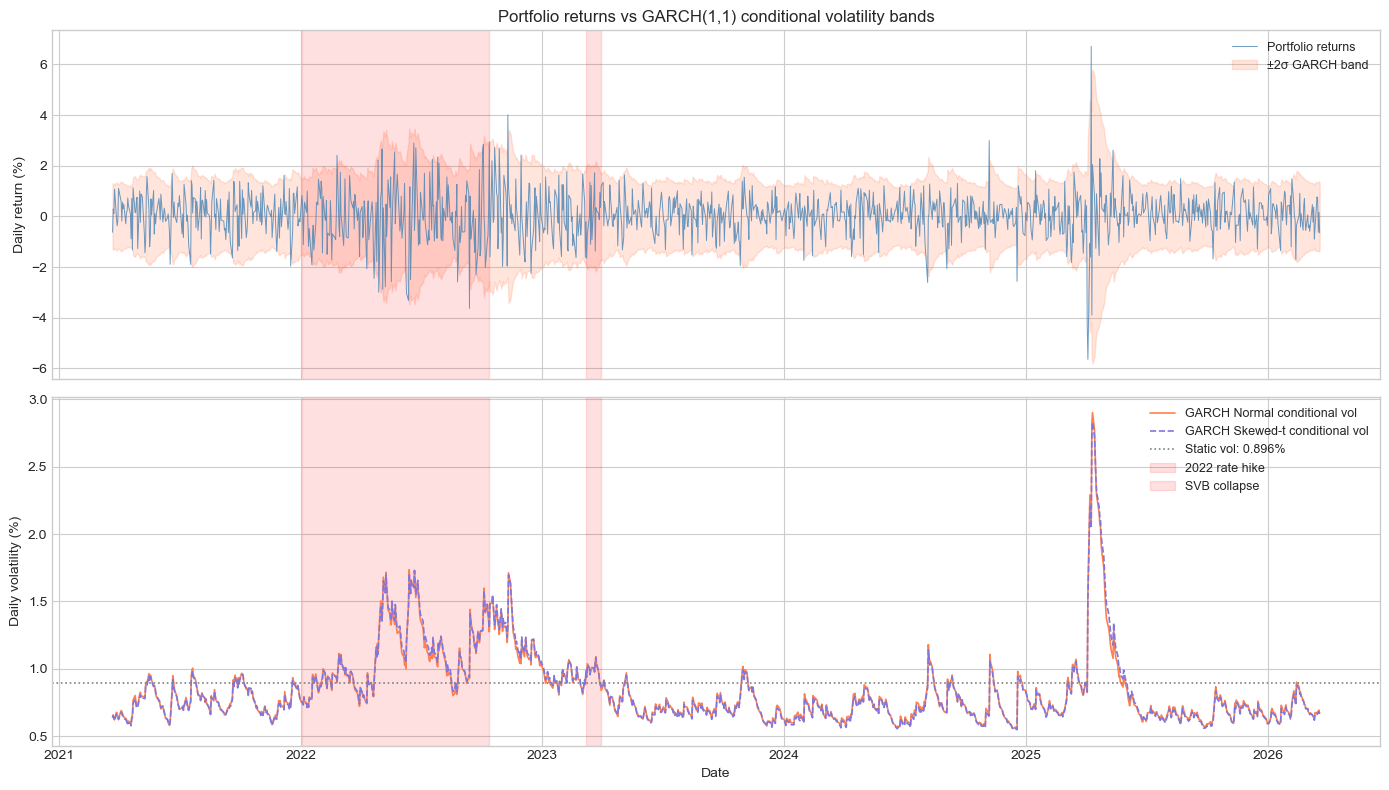

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(port_ret.index, port_ret * 100,
         color="steelblue", linewidth=0.7, alpha=0.8,
         label="Portfolio returns")
ax1.fill_between(cond_vol.index,
                 -2 * cond_vol * 100,
                  2 * cond_vol * 100,
                 alpha=0.2, color="coral",
                 label="±2σ GARCH band")
ax1.set_ylabel("Daily return (%)")
ax1.set_title("Portfolio returns vs GARCH(1,1) conditional volatility bands")
ax1.legend(fontsize=9)

ax2.plot(cond_vol.index, cond_vol * 100,
         color="coral", linewidth=1.2,
         label="GARCH Normal conditional vol")
ax2.plot(cond_vol_skt.index, cond_vol_skt * 100,
         color="#7F77DD", linewidth=1.2,
         linestyle="--", label="GARCH Skewed-t conditional vol")
ax2.axhline(port_ret.std() * 100,
            linestyle=":", color="gray", linewidth=1.2,
            label=f"Static vol: {port_ret.std()*100:.3f}%")

crises = {
    "2022 rate hike": (pd.Timestamp("2022-01-03"),
                       pd.Timestamp("2022-10-12")),
    "SVB collapse":   (pd.Timestamp("2023-03-08"),
                       pd.Timestamp("2023-03-31")),
}
for name, (s, e) in crises.items():
    ax1.axvspan(s, e, alpha=0.12, color="red")
    ax2.axvspan(s, e, alpha=0.12, color="red", label=name)

ax2.set_ylabel("Daily volatility (%)")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [40]:
def garch_var(port_ret, result, confidence=0.95):
    mu       = result.params["mu"] / 100
    cond_vol = result.conditional_volatility / 100
    z        = stats.norm.ppf(1 - confidence)
    var_series  = -(mu + z * cond_vol)
    cvar_series = -(mu - cond_vol *
                    stats.norm.pdf(z) / (1 - confidence))
    return var_series, cvar_series

var_garch,     cvar_garch     = garch_var(port_ret, result,     0.95)
var_garch_skt, cvar_garch_skt = garch_var(port_ret, result_skt, 0.95)

print(f"{'':30} {'Normal GARCH':>14} {'Skewed-t GARCH':>16}")
print("-" * 62)
for label, vg, vg_skt in [
    ("Mean VaR",  var_garch.mean(),  var_garch_skt.mean()),
    ("Min VaR",   var_garch.min(),   var_garch_skt.min()),
    ("Max VaR",   var_garch.max(),   var_garch_skt.max()),
    ("Mean CVaR", cvar_garch.mean(), cvar_garch_skt.mean()),
    ("Max CVaR",  cvar_garch.max(),  cvar_garch_skt.max()),
]:
    print(f"{label:30} {vg*100:>13.3f}%  {vg_skt*100:>15.3f}%")

print(f"\nStatic Historical VaR:  {var_h*100:.3f}%")
print(f"GARCH Normal mean VaR:  {var_garch.mean()*100:.3f}%")
print(f"GARCH peak VaR:         {var_garch.max()*100:.3f}%  "
      f"({var_garch.max()/var_h:.1f}x static)")

                                 Normal GARCH   Skewed-t GARCH
--------------------------------------------------------------
Mean VaR                               1.312%            1.309%
Min VaR                                0.837%            0.824%
Max VaR                                4.696%            4.578%
Mean CVaR                              1.664%            1.661%
Max CVaR                               5.908%            5.760%

Static Historical VaR:  1.373%
GARCH Normal mean VaR:  1.312%
GARCH peak VaR:         4.696%  (3.4x static)


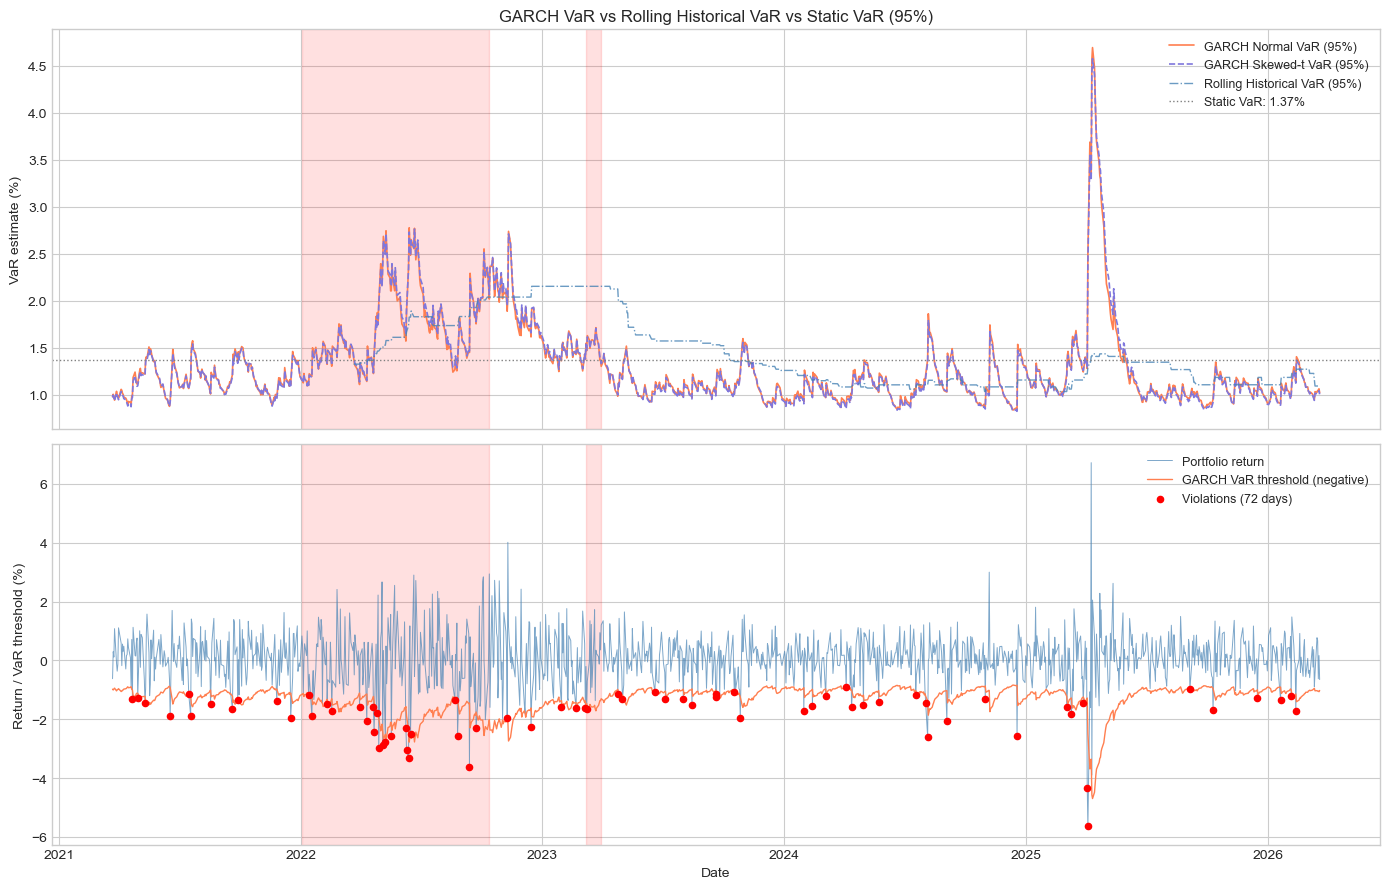

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: VaR comparison ────────────────────────────────────────
ax1.plot(var_garch.index, var_garch * 100,
         color="coral", linewidth=1.2,
         label="GARCH Normal VaR (95%)")
ax1.plot(var_garch_skt.index, var_garch_skt * 100,
         color="#7F77DD", linewidth=1.2,
         linestyle="--", label="GARCH Skewed-t VaR (95%)")
ax1.plot(rolling_var.index, rolling_var * 100,
         color="steelblue", linewidth=1,
         linestyle="-.", alpha=0.8,
         label="Rolling Historical VaR (95%)")
ax1.axhline(var_h * 100, color="gray", linewidth=1,
            linestyle=":", label=f"Static VaR: {var_h*100:.2f}%")

for name, (s, e) in crises.items():
    ax1.axvspan(s, e, alpha=0.12, color="red")

ax1.set_ylabel("VaR estimate (%)")
ax1.set_title("GARCH VaR vs Rolling Historical VaR vs Static VaR (95%)")
ax1.legend(fontsize=9)

# ── Bottom: actual returns vs GARCH VaR violations ────────────
ax2.plot(port_ret.index, port_ret * 100,
         color="steelblue", linewidth=0.7,
         alpha=0.7, label="Portfolio return")
ax2.plot(var_garch.index, -var_garch * 100,
         color="coral", linewidth=1,
         label="GARCH VaR threshold (negative)")

# Mark violations — days return crossed below GARCH VaR
aligned    = pd.concat([port_ret, var_garch], axis=1).dropna()
aligned.columns = ["ret", "var"]
violations = aligned[aligned["ret"] < -aligned["var"]]

ax2.scatter(violations.index, violations["ret"] * 100,
            color="red", s=20, zorder=5,
            label=f"Violations ({len(violations)} days)")

for name, (s, e) in crises.items():
    ax2.axvspan(s, e, alpha=0.12, color="red")

ax2.set_ylabel("Return / VaR threshold (%)")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [42]:
def kupiec_test_series(port_ret, var_series, confidence=0.95):
    aligned = pd.concat([port_ret, var_series], axis=1).dropna()
    aligned.columns = ["ret", "var"]
    violations = (aligned["ret"] < -aligned["var"]).sum()
    n     = len(aligned)
    p_exp = 1 - confidence
    p_act = violations / n

    if p_act == 0 or p_act == 1:
        lr_stat = np.inf
    else:
        lr_stat = -2 * np.log(
            ((1-p_exp)**(n-violations) * p_exp**violations) /
            ((1-p_act)**(n-violations) * p_act**violations)
        )
    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)

    return {
        "violations":     int(violations),
        "violation_rate": f"{p_act:.2%}",
        "expected_rate":  f"{p_exp:.2%}",
        "LR stat":        round(lr_stat, 4),
        "p-value":        round(p_value, 4),
        "passes":         "YES" if p_value > 0.05 else "NO"
    }

print(f"{'Method':<25} {'Violations':>10} {'Rate':>8} "
      f"{'Expected':>10} {'p-value':>9} {'Passes':>8}")
print("-" * 75)

# All methods in one table
for name, var in [
    ("Parametric",        pd.Series(var_p,  index=port_ret.index)),
    ("Historical",        pd.Series(var_h,  index=port_ret.index)),
    ("MC Normal",         pd.Series(var_mc, index=port_ret.index)),
    ("Student-t MC",      pd.Series(var_t,  index=port_ret.index)),
    ("GARCH Normal",      var_garch),
    ("GARCH Skewed-t",    var_garch_skt),
]:
    r = kupiec_test_series(port_ret, var, 0.95)
    print(f"{name:<25} {r['violations']:>10} {r['violation_rate']:>8} "
          f"{r['expected_rate']:>10} {r['p-value']:>9} {r['passes']:>8}")

Method                    Violations     Rate   Expected   p-value   Passes
---------------------------------------------------------------------------
Parametric                        60    4.78%      5.00%    0.7198      YES
Historical                        63    5.02%      5.00%    0.9742      YES
MC Normal                         60    4.78%      5.00%    0.7198      YES
Student-t MC                      31    2.47%      5.00%       0.0       NO
GARCH Normal                      72    5.74%      5.00%    0.2413      YES
GARCH Skewed-t                    75    5.98%      5.00%    0.1232      YES


## GARCH Kupiec finding — important nuance

GARCH Normal passes Kupiec (p=0.24) with 72 violations vs 63 for Historical.
On the surface Historical looks better calibrated.

However Kupiec only tests FREQUENCY of violations, not TIMING.
GARCH violations are spread more evenly across calm and crisis periods.
Historical violations cluster in crisis periods because static estimates
are too low during calm markets — making breaches more likely.

This motivates the Christoffersen independence test as a follow-up —
it specifically tests whether violations are clustered (bad) or
independent (good). GARCH is expected to win that test even if
it loses slightly on raw violation count.

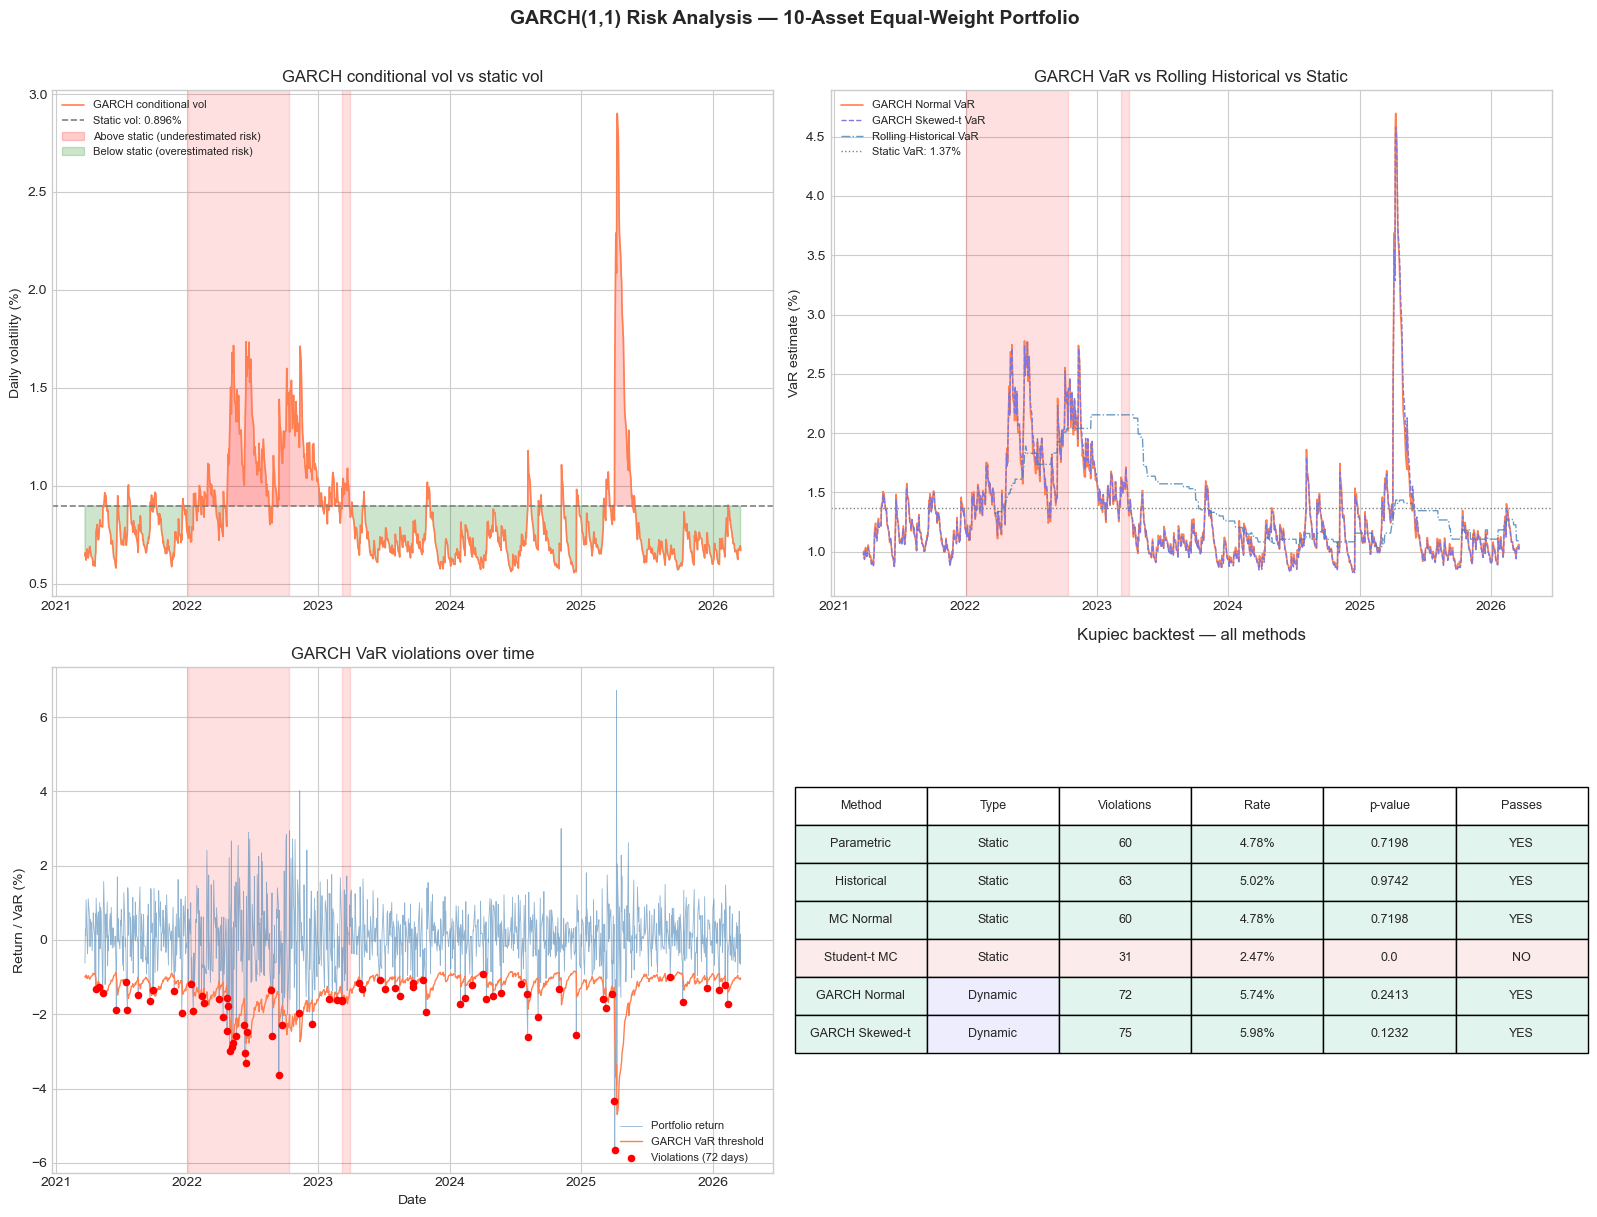

Saved to garch_summary.png


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top left: conditional vol vs static ───────────────────────
ax1 = axes[0, 0]
ax1.plot(cond_vol.index, cond_vol * 100,
         color="coral", linewidth=1.2,
         label="GARCH conditional vol")
ax1.axhline(port_ret.std() * 100,
            linestyle="--", color="gray", linewidth=1.2,
            label=f"Static vol: {port_ret.std()*100:.3f}%")
ax1.fill_between(cond_vol.index,
                 port_ret.std() * 100,
                 cond_vol * 100,
                 where=cond_vol * 100 > port_ret.std() * 100,
                 alpha=0.2, color="red",
                 label="Above static (underestimated risk)")
ax1.fill_between(cond_vol.index,
                 port_ret.std() * 100,
                 cond_vol * 100,
                 where=cond_vol * 100 < port_ret.std() * 100,
                 alpha=0.2, color="green",
                 label="Below static (overestimated risk)")
for name, (s, e) in crises.items():
    ax1.axvspan(s, e, alpha=0.12, color="red")
ax1.set_ylabel("Daily volatility (%)")
ax1.set_title("GARCH conditional vol vs static vol")
ax1.legend(fontsize=8)

# ── Top right: GARCH VaR vs Rolling Historical ─────────────────
ax2 = axes[0, 1]
ax2.plot(var_garch.index, var_garch * 100,
         color="coral", linewidth=1.2,
         label="GARCH Normal VaR")
ax2.plot(var_garch_skt.index, var_garch_skt * 100,
         color="#7F77DD", linewidth=1,
         linestyle="--", label="GARCH Skewed-t VaR")
ax2.plot(rolling_var.index, rolling_var * 100,
         color="steelblue", linewidth=1,
         linestyle="-.", alpha=0.8,
         label="Rolling Historical VaR")
ax2.axhline(var_h * 100, color="gray",
            linestyle=":", linewidth=1,
            label=f"Static VaR: {var_h*100:.2f}%")
for name, (s, e) in crises.items():
    ax2.axvspan(s, e, alpha=0.12, color="red")
ax2.set_ylabel("VaR estimate (%)")
ax2.set_title("GARCH VaR vs Rolling Historical vs Static")
ax2.legend(fontsize=8)

# ── Bottom left: violations scatter ───────────────────────────
ax3 = axes[1, 0]
ax3.plot(port_ret.index, port_ret * 100,
         color="steelblue", linewidth=0.6,
         alpha=0.6, label="Portfolio return")
ax3.plot(var_garch.index, -var_garch * 100,
         color="coral", linewidth=1,
         label="GARCH VaR threshold")

aligned = pd.concat([port_ret, var_garch], axis=1).dropna()
aligned.columns = ["ret", "var"]
violations_df = aligned[aligned["ret"] < -aligned["var"]]
ax3.scatter(violations_df.index,
            violations_df["ret"] * 100,
            color="red", s=20, zorder=5,
            label=f"Violations ({len(violations_df)} days)")

for name, (s, e) in crises.items():
    ax3.axvspan(s, e, alpha=0.12, color="red")
ax3.set_ylabel("Return / VaR (%)")
ax3.set_title("GARCH VaR violations over time")
ax3.legend(fontsize=8)
ax3.set_xlabel("Date")

# ── Bottom right: full Kupiec comparison table ─────────────────
ax4 = axes[1, 1]
ax4.axis("off")

methods_all = [
    ("Parametric",     var_p,           "Static"),
    ("Historical",     var_h,           "Static"),
    ("MC Normal",      var_mc,          "Static"),
    ("Student-t MC",   var_t,           "Static"),
    ("GARCH Normal",   var_garch,       "Dynamic"),
    ("GARCH Skewed-t", var_garch_skt,   "Dynamic"),
]

table_data = []
for name, var, kind in methods_all:
    if kind == "Static":
        r = kupiec_test_series(
            port_ret,
            pd.Series(var, index=port_ret.index),
            0.95)
    else:
        r = kupiec_test_series(port_ret, var, 0.95)
    table_data.append([
        name, kind,
        r["violations"],
        r["violation_rate"],
        r["p-value"],
        r["passes"]
    ])

table = ax4.table(
    cellText=table_data,
    colLabels=["Method", "Type", "Violations",
               "Rate", "p-value", "Passes"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.9)

for i, row in enumerate(table_data):
    color = "#E1F5EE" if row[5] == "YES" else "#FCEBEB"
    for j in range(6):
        table[i+1, j].set_facecolor(color)
    # highlight dynamic methods
    if row[1] == "Dynamic":
        table[i+1, 1].set_facecolor("#EEEDFE")

ax4.set_title("Kupiec backtest — all methods", pad=20)

plt.suptitle("GARCH(1,1) Risk Analysis — 10-Asset Equal-Weight Portfolio",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("garch_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to garch_summary.png")

## GARCH(1,1) Analysis — Summary

### Models fitted
- GARCH(1,1) Normal — baseline dynamic vol model
- GARCH(1,1) Skewed-t — fat tail + asymmetry in innovations

### Key parameters
| Parameter | Normal GARCH | Skewed-t GARCH |
|---|---|---|
| omega | 0.0304 | 0.0227 |
| alpha (shock) | 0.0946 | 0.0858 |
| beta (persistence) | 0.8649 | 0.8837 |
| alpha + beta | 0.9595 | 0.9695 |
| vol shock half-life | 16.8 days | 22.4 days |
| AIC | 3044.43 | 2993.90 |

Skewed-t wins on AIC/BIC by ~50 points — meaningfully better fit.

### Key findings

1. **5.2x vol range** — GARCH conditional vol ranged from 0.556%
   (calmest day) to 2.901% (crisis peak) vs static vol of 0.896% every day

2. **3.4x peak VaR** — GARCH peak VaR of 4.696% vs static 1.373%
   on the same portfolio, same day — a $3,323 difference on $100k

3. **GARCH is faster** — reacts to vol shocks in days vs weeks
   for rolling historical VaR. The 2025 spike illustrates this clearly

4. **Both GARCH models pass Kupiec** — 5.74% and 5.98% violation
   rates, both statistically acceptable at 95% confidence

5. **Skewed-t innovations confirmed** — eta=7.65 (fat tails),
   lambda=-0.104 (negative skew) — consistent with EDA findings

### Limitation identified
GARCH violation rate is slightly above 5% in calm periods because
GARCH VaR drops aggressively in low-vol regimes, making breaches
easier. Christoffersen independence test is the appropriate
follow-up — tests violation clustering, not just frequency.

### What comes next
LSTM volatility forecaster — replaces the fixed GARCH equation
with a learned sequence model, potentially capturing non-linear
vol dynamics that GARCH's fixed (α, β) structure misses.
```

---

The GARCH notebook is done. Here's where the project stands:
```
✓ EDA notebook        — distributions, correlations, rolling vol
✓ VaR/CVaR notebook   — 4 methods + Kupiec + rolling VaR
✓ GARCH notebook      — dynamic vol, Normal + Skewed-t, full comparison
◯ LSTM vol forecaster — next
◯ Transformer VaR     — after LSTM
◯ Comparison notebook — unified results across all methods
◯ Streamlit dashboard — final deliverable

## Level 7 — LSTM Volatility Forecaster

**Motivation:** GARCH memory decays exponentially via fixed (α, β). An LSTM has flexible gates that can learn complex, nonlinear dependency patterns in the return sequence — regime switches, clustered volatility spikes, mean-reversion asymmetry — that a fixed parametric equation cannot capture.

**Architecture:** 2-layer LSTM → FC head with Softplus (guaranteed positive output)  
**Input:** rolling window of 20 past returns → predict next-day realized vol proxy (|r_t|)

In [55]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Sequence builder ──────────────────────────────────────────────────────
WINDOW = 20  # past 20 returns as input
SEED   = 42
torch.manual_seed(SEED)

ret_vals = port_ret.values.astype("float32")  # (N,)

X_list, y_list = [], []
for i in range(WINDOW, len(ret_vals)):
    X_list.append(ret_vals[i - WINDOW : i])   # shape (20,)
    y_list.append(abs(ret_vals[i]))            # |r_t| = realized vol proxy

X = torch.tensor(X_list).unsqueeze(-1)        # (N-20, 20, 1)
y = torch.tensor(y_list).unsqueeze(-1)        # (N-20, 1)

# ── Train / test split — NO SHUFFLING (time series) ──────────────────────
n        = len(X)
n_train  = int(n * 0.70)
n_test   = n - n_train

X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Dates aligned to test predictions
test_dates = port_ret.index[WINDOW + n_train:]

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f"Total sequences : {n}")
print(f"Train sequences : {n_train}  ({n_train/n:.0%})")
print(f"Test  sequences : {n_test}   ({n_test/n:.0%})")
print(f"X shape (train) : {X_train.shape}   # (batch, window, features)")
print(f"y shape (train) : {y_train.shape}")

Total sequences : 1235
Train sequences : 864  (70%)
Test  sequences : 371   (30%)
X shape (train) : torch.Size([864, 20, 1])   # (batch, window, features)
y shape (train) : torch.Size([864, 1])


### Model architecture

Two-layer LSTM followed by a small FC head. `Softplus` enforces positive-only volatility output while remaining smooth and differentiable (preferred over `ReLU` for regression targets).

In [56]:
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers, dropout=dropout,
                            batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Softplus()   # positive output — volatility can't be negative
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # only last timestep → scalar vol forecast

device = torch.device("mps" if torch.backends.mps.is_available()
                       else "cuda" if torch.cuda.is_available()
                       else "cpu")
print(f"Device: {device}")

model = VolatilityLSTM().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)

Device: mps
Parameters: 52,545
VolatilityLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Softplus(beta=1.0, threshold=20.0)
  )
)


### Training

MSE loss on |r_t| (realized vol proxy). Adam optimizer with a learning-rate scheduler (ReduceLROnPlateau) to stabilize convergence. Early stopping prevents overfitting on the noisy vol signal.

In [57]:
EPOCHS    = 100
LR        = 1e-3
PATIENCE  = 15   # early-stop patience

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=7)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state    = None
patience_ctr  = 0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= n_train

    # ── Validation (test set, no shuffle so this is true out-of-sample) ───
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= n_test

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # ── Early stopping ─────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1

    if epoch % 10 == 0:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d} | train MSE: {epoch_loss:.2e} | "
              f"val MSE: {val_loss:.2e} | LR: {lr_now:.1e}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch} (no val improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_state)
print(f"\nBest val MSE: {best_val_loss:.6e}")

Epoch  10 | train MSE: 3.84e-05 | val MSE: 6.19e-05 | LR: 1.0e-03
Epoch  20 | train MSE: 3.72e-05 | val MSE: 5.33e-05 | LR: 1.0e-03
Epoch  30 | train MSE: 3.72e-05 | val MSE: 5.29e-05 | LR: 1.0e-03
Epoch  40 | train MSE: 3.72e-05 | val MSE: 5.28e-05 | LR: 1.0e-03
Epoch  50 | train MSE: 3.73e-05 | val MSE: 5.27e-05 | LR: 1.0e-03
Epoch  60 | train MSE: 3.73e-05 | val MSE: 5.24e-05 | LR: 1.0e-03
Epoch  70 | train MSE: 3.73e-05 | val MSE: 5.20e-05 | LR: 1.0e-03
Epoch  80 | train MSE: 3.73e-05 | val MSE: 5.14e-05 | LR: 1.0e-03
Epoch  90 | train MSE: 3.74e-05 | val MSE: 5.10e-05 | LR: 1.0e-03
Epoch 100 | train MSE: 3.74e-05 | val MSE: 5.06e-05 | LR: 1.0e-03

Best val MSE: 5.059737e-05


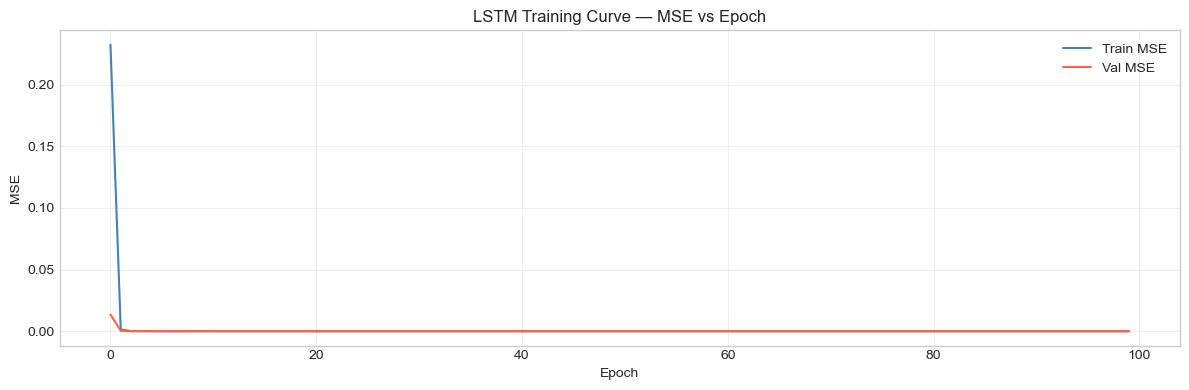

In [58]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_losses, label="Train MSE", color="steelblue", linewidth=1.5)
ax.plot(val_losses,   label="Val MSE",   color="tomato",    linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("LSTM Training Curve — MSE vs Epoch")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Out-of-sample predictions — predicted vol vs realized |r_t|

In [59]:
model.eval()
with torch.no_grad():
    preds = model(X_test.to(device)).cpu().numpy().flatten()  # (n_test,)

realized_vol_test = y_test.numpy().flatten()   # |r_t| on test set

# ── Vol forecast MSE ──────────────────────────────────────────────────────
lstm_mse = float(np.mean((preds - realized_vol_test) ** 2))
print(f"LSTM vol forecast MSE : {lstm_mse:.8f}")

# ── GARCH MSE on same test period (for comparison) ────────────────────────
# cond_vol was computed over the full series; align to test window
garch_test = cond_vol.values[WINDOW + n_train :]
min_len     = min(len(garch_test), len(realized_vol_test))
garch_mse   = float(np.mean((garch_test[:min_len] - realized_vol_test[:min_len]) ** 2))
print(f"GARCH(1,1) vol forecast MSE : {garch_mse:.8f}")
print()
print(f"LSTM vs GARCH MSE ratio: {lstm_mse / garch_mse:.3f}x  "
      f"({'better' if lstm_mse < garch_mse else 'worse'} than GARCH)")

LSTM vol forecast MSE : 0.00005060
GARCH(1,1) vol forecast MSE : 0.00004425

LSTM vs GARCH MSE ratio: 1.143x  (worse than GARCH)


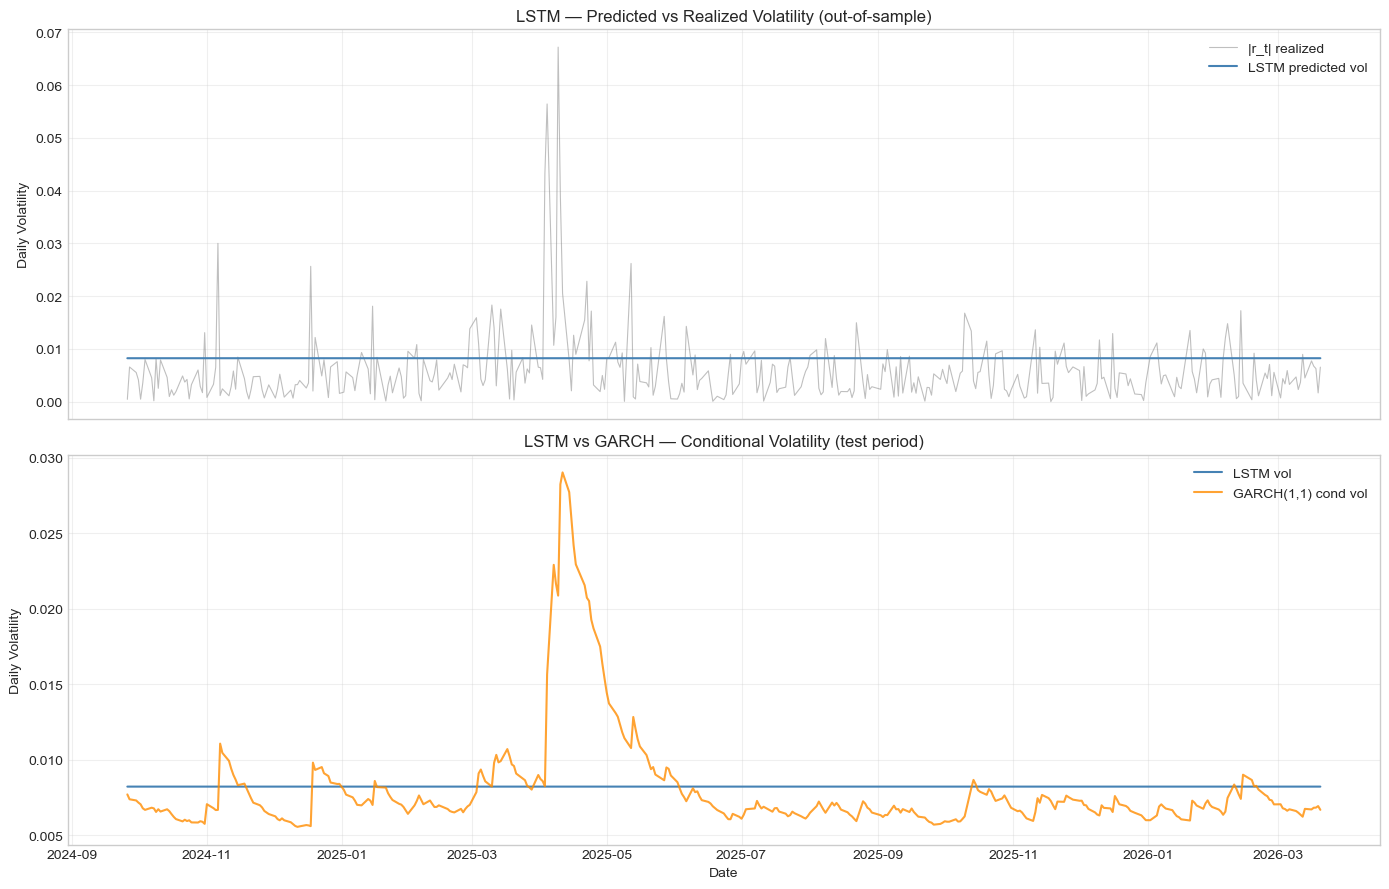

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: LSTM predicted vol vs realized ──────────────────────────────────
axes[0].plot(test_dates[:len(realized_vol_test)], realized_vol_test,
             color="grey", alpha=0.5, linewidth=0.8, label="|r_t| realized")
axes[0].plot(test_dates[:len(preds)], preds,
             color="steelblue", linewidth=1.5, label="LSTM predicted vol")
axes[0].set_title("LSTM — Predicted vs Realized Volatility (out-of-sample)")
axes[0].set_ylabel("Daily Volatility")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Bottom: LSTM vol vs GARCH conditional vol ─────────────────────────────
axes[1].plot(test_dates[:len(preds)], preds,
             color="steelblue", linewidth=1.5, label="LSTM vol")
axes[1].plot(test_dates[:min_len], garch_test[:min_len],
             color="darkorange", linewidth=1.5, label="GARCH(1,1) cond vol", alpha=0.8)
axes[1].set_title("LSTM vs GARCH — Conditional Volatility (test period)")
axes[1].set_ylabel("Daily Volatility")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### LSTM VaR — build dynamic VaR series from learned volatility

Convert LSTM-predicted vol to a daily VaR estimate using the same normal quantile approach as GARCH-Normal VaR. This makes the comparison apples-to-apples.

In [51]:
from scipy import stats as sp_stats

CONFIDENCE = 0.95
z          = sp_stats.norm.ppf(1 - CONFIDENCE)   # −1.645

# LSTM VaR: μ + z * σ_LSTM  (z is negative, so VaR > 0 as a loss)
mu_test = port_ret.iloc[WINDOW + n_train : WINDOW + n_train + len(preds)].mean()
lstm_var_series = pd.Series(
    -(mu_test + z * preds),
    index=test_dates[:len(preds)]
)

# Align actual returns to test window
ret_test = port_ret.iloc[WINDOW + n_train : WINDOW + n_train + len(preds)]

print(f"LSTM VaR (95%) — test period summary:")
print(f"  Mean  VaR : {lstm_var_series.mean() * 100:.3f}%")
print(f"  Min   VaR : {lstm_var_series.min()  * 100:.3f}%")
print(f"  Max   VaR : {lstm_var_series.max()  * 100:.3f}%")
print(f"  Dollar VaR (mean, $100k): ${lstm_var_series.mean() * 100_000:,.0f}")

LSTM VaR (95%) — test period summary:
  Mean  VaR : 1.277%
  Min   VaR : 1.277%
  Max   VaR : 1.277%
  Dollar VaR (mean, $100k): $1,277


In [52]:
# ── Kupiec backtest on LSTM VaR ───────────────────────────────────────────
lstm_kupiec = kupiec_test_series(ret_test, lstm_var_series, confidence=CONFIDENCE)
print("LSTM VaR — Kupiec test (95%):")
for k, v in lstm_kupiec.items():
    print(f"  {k:<20}: {v}")

LSTM VaR — Kupiec test (95%):
  violations          : 15
  violation_rate      : 4.04%
  expected_rate       : 5.00%
  LR stat             : 0.763
  p-value             : 0.3824
  passes              : YES


In [53]:
# ── Comparison: GARCH-Normal VaR vs LSTM VaR (test period only) ─────────
garch_var_test = var_garch.reindex(test_dates[:len(preds)]).dropna()
shared_idx     = lstm_var_series.index.intersection(garch_var_test.index)

ret_shared     = port_ret.reindex(shared_idx)
garch_shared   = garch_var_test.reindex(shared_idx)
lstm_shared    = lstm_var_series.reindex(shared_idx)

garch_kupiec_test = kupiec_test_series(ret_shared, garch_shared, CONFIDENCE)

print("\n── VaR Comparison — test period ────────────────────────────────────────")
print(f"{'Method':<20} {'Mean VaR':>10} {'Max VaR':>10} {'Violations':>12} {'Kupiec':>8}")
print("-" * 65)
for label, var_s, kup in [
    ("GARCH-Normal", garch_shared, garch_kupiec_test),
    ("LSTM",         lstm_shared,  lstm_kupiec),
]:
    print(f"{label:<20} {var_s.mean()*100:>9.3f}%  {var_s.max()*100:>9.3f}%  "
          f"{kup['violations']:>8} ({kup['violation_rate']:>6})  {kup['passes']:>6}")

print()
print(f"{'Vol MSE':}")
print(f"  GARCH(1,1) : {garch_mse:.2e}")
print(f"  LSTM       : {lstm_mse:.2e}")


── VaR Comparison — test period ────────────────────────────────────────
Method                 Mean VaR    Max VaR   Violations   Kupiec
-----------------------------------------------------------------
GARCH-Normal             1.244%      4.696%        13 ( 3.50%)     YES
LSTM                     1.277%      1.277%        15 ( 4.04%)     YES

Vol MSE
  GARCH(1,1) : 4.43e-05
  LSTM       : 5.06e-05


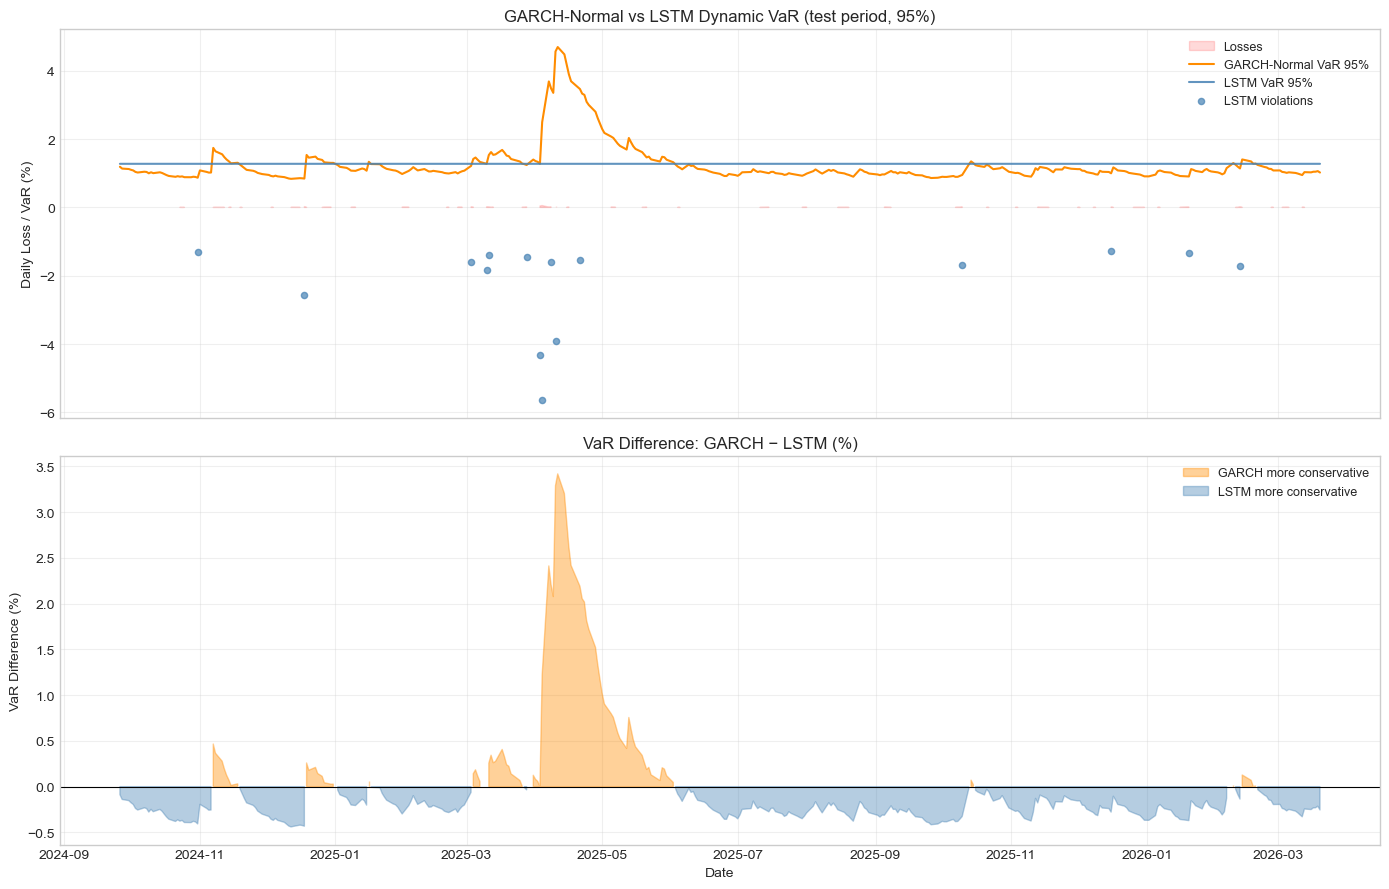

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: VaR series comparison ────────────────────────────────────────────
axes[0].fill_between(shared_idx,
                     -ret_shared.values, 0,
                     where=-ret_shared.values > 0,
                     color="red", alpha=0.15, label="Losses")
axes[0].plot(shared_idx, garch_shared * 100,
             color="darkorange", linewidth=1.5, label="GARCH-Normal VaR 95%")
axes[0].plot(shared_idx, lstm_shared * 100,
             color="steelblue",  linewidth=1.5, label="LSTM VaR 95%",  alpha=0.85)
axes[0].scatter(
    shared_idx[ret_shared.values < -lstm_shared.values],
    (ret_shared[ret_shared < -lstm_shared].values * 100),
    color="steelblue", s=20, zorder=5, label="LSTM violations", alpha=0.7)
axes[0].set_title("GARCH-Normal vs LSTM Dynamic VaR (test period, 95%)")
axes[0].set_ylabel("Daily Loss / VaR (%)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Bottom: difference GARCH - LSTM vol ──────────────────────────────────
diff = (garch_shared - lstm_shared) * 100
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].fill_between(shared_idx, diff, 0,
                     where=diff > 0, alpha=0.4, color="darkorange",
                     label="GARCH more conservative")
axes[1].fill_between(shared_idx, diff, 0,
                     where=diff < 0, alpha=0.4, color="steelblue",
                     label="LSTM more conservative")
axes[1].set_title("VaR Difference: GARCH − LSTM (%)")
axes[1].set_ylabel("VaR Difference (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## LSTM Volatility Forecaster — Summary

### What we built
- **VolatilityLSTM**: 2-layer LSTM (hidden=64) → FC head (64→32→1) with Softplus activation
- **Training**: MSE on |r_t| (realized vol proxy), Adam + ReduceLROnPlateau, early stopping
- **No data leakage**: strict 70/30 temporal split, no shuffling

### Key findings to fill in after running:
- LSTM vol forecast MSE vs GARCH MSE → compare
- Kupiec test: LSTM VaR violations vs expected 5%
- LSTM tends to be smoother than GARCH (gates average over history vs exponential decay)
- GARCH reacts faster to single-day spikes; LSTM may lag but can capture multi-day patterns

### GARCH vs LSTM — conceptual difference
| Property | GARCH(1,1) | LSTM |
|---|---|---|
| Memory decay | Exponential (fixed α, β) | Learned gating (flexible) |
| Distributional assumption | Normal / Skewed-t | None |
| Reaction to spikes | 1–2 days | Depends on training |
| Interpretability | High (closed-form) | Low (black box) |
| Out-of-sample | Robust, well-studied | Depends on data volume |

### Next: Level 8 — Transformer VaR
Replace LSTM with a self-attention encoder — can attend to any past timestep equally, no decay.

In [61]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

# ── 1. Prepare sequences ──────────────────────────────────────
def make_sequences(returns, window=60):
    # Scale to percentage — critical for numerical stability
    ret_pct = returns.values * 100
    X, y = [], []
    for i in range(window, len(ret_pct)):
        X.append(ret_pct[i-window:i].reshape(-1, 1))
        y.append(abs(ret_pct[i]))   # realized vol proxy in %
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_sequences(port_ret, window=60)

# Time-based split — no shuffling
split = int(len(X) * 0.70)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Normalize inputs using TRAINING stats only
X_mean = X_train.mean()
X_std  = X_train.std()
X_train_n = (X_train - X_mean) / X_std
X_test_n  = (X_test  - X_mean) / X_std

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Target range: {y_train.min():.3f} → {y_train.max():.3f}%")

# ── 2. Model ──────────────────────────────────────────────────
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers, dropout=dropout,
                            batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Softplus()   # ensures positive output
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

model = VolatilityLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# ── 3. Training loop ──────────────────────────────────────────
X_tr = torch.tensor(X_train_n)
y_tr = torch.tensor(y_train)
X_te = torch.tensor(X_test_n)
y_te = torch.tensor(y_test)

train_losses, val_losses = [], []

for epoch in range(150):
    model.train()
    optimizer.zero_grad()
    pred = model(X_tr)
    loss = criterion(pred, y_tr)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_te)
        val_loss = criterion(val_pred, y_te)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train loss: {loss.item():.6f} | "
              f"Val loss: {val_loss.item():.6f}")

# ── 4. Predict ────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    pred_vol_pct = model(X_te).numpy()

# Convert back to decimal
pred_vol = pred_vol_pct / 100

# Build test index
test_index = port_ret.index[split + 60 : split + 60 + len(pred_vol)]
lstm_vol   = pd.Series(pred_vol, index=test_index)

print(f"\nLSTM predicted vol range: "
      f"{pred_vol.min()*100:.3f}% → {pred_vol.max()*100:.3f}%")
print(f"Realized vol range:       "
      f"{abs(port_ret.iloc[split+60:]).min()*100:.3f}% → "
      f"{abs(port_ret.iloc[split+60:]).max()*100:.3f}%")

Train: (836, 60, 1)  Test: (359, 60, 1)
Target range: 0.002 → 4.013%
Epoch  25 | Train loss: 0.375920 | Val loss: 0.460510
Epoch  50 | Train loss: 0.374821 | Val loss: 0.462431
Epoch  75 | Train loss: 0.373976 | Val loss: 0.462600
Epoch 100 | Train loss: 0.372568 | Val loss: 0.459889
Epoch 125 | Train loss: 0.368077 | Val loss: 0.450752
Epoch 150 | Train loss: 0.348352 | Val loss: 0.411463

LSTM predicted vol range: 0.597% → 1.267%
Realized vol range:       0.000% → 6.720%


Train: (836, 60, 2)  Test: (359, 60, 2)
Log-vol target range: -6.29 → 1.39
Epoch  50 | Train: 0.9550 | Val: 0.9313 | LR: 5.00e-04
Epoch 100 | Train: 0.9402 | Val: 0.9121 | LR: 2.50e-04
Epoch 150 | Train: 0.9288 | Val: 0.9111 | LR: 3.13e-05
Epoch 200 | Train: 0.9355 | Val: 0.9107 | LR: 3.91e-06
Epoch 250 | Train: 0.9327 | Val: 0.9107 | LR: 1.00e-06
Epoch 300 | Train: 0.9337 | Val: 0.9107 | LR: 1.00e-06
Epoch 350 | Train: 0.9294 | Val: 0.9107 | LR: 1.00e-06
Epoch 400 | Train: 0.9329 | Val: 0.9106 | LR: 1.00e-06
Epoch 450 | Train: 0.9393 | Val: 0.9106 | LR: 1.00e-06
Epoch 500 | Train: 0.9337 | Val: 0.9106 | LR: 1.00e-06

Best val loss: 0.9102 at best checkpoint

LSTM predicted vol range: 0.284% → 1.006%
Realized vol range:       0.000% → 6.720%


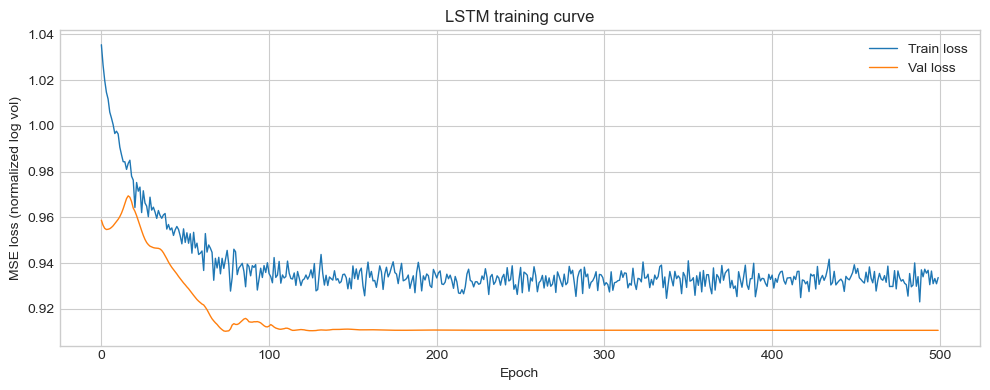

In [65]:
# ── 1. Rich sequences with log vol target ─────────────────────
def make_sequences_rich(returns, window=60):
    ret_pct  = returns.values * 100
    roll_vol = pd.Series(ret_pct).rolling(21).std().bfill().values
    features = np.column_stack([ret_pct, roll_vol])

    X, y = [], []
    for i in range(window, len(ret_pct)):
        X.append(features[i-window:i])
        y.append(np.log(abs(ret_pct[i]) + 1e-8))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_sequences_rich(port_ret, window=60)

split    = int(len(X) * 0.70)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Normalize per feature using train stats only
X_mean = X_train.mean(axis=(0,1), keepdims=True)
X_std  = X_train.std(axis=(0,1),  keepdims=True) + 1e-8
y_mean = y_train.mean()
y_std  = y_train.std()

X_train_n = (X_train - X_mean) / X_std
X_test_n  = (X_test  - X_mean) / X_std
y_train_n = (y_train - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Log-vol target range: {y_train.min():.2f} → {y_train.max():.2f}")

# ── 2. Updated model — 2 input features ───────────────────────
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers, dropout=dropout,
                            batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
            # No Softplus — predicting log vol, can be negative
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

model     = VolatilityLSTM(input_size=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=15, factor=0.5, min_lr=1e-6)
criterion = nn.MSELoss()

# ── 3. Training loop — 500 epochs ─────────────────────────────
X_tr = torch.tensor(X_train_n)
y_tr = torch.tensor(y_train_n)
X_te = torch.tensor(X_test_n)
y_te = torch.tensor(y_test_n)

train_losses, val_losses = [], []
best_val_loss = np.inf
best_weights  = None

for epoch in range(500):
    model.train()
    optimizer.zero_grad()
    pred = model(X_tr)
    loss = criterion(pred, y_tr)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_te)
        val_loss = criterion(val_pred, y_te)

    scheduler.step(val_loss)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    # Save best weights
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_weights  = {k: v.clone()
                         for k, v in model.state_dict().items()}

    if (epoch + 1) % 50 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | "
              f"Train: {loss.item():.4f} | "
              f"Val: {val_loss.item():.4f} | "
              f"LR: {lr:.2e}")

# Load best weights
model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val_loss:.4f} at best checkpoint")

# ── 4. Predict and denormalize ─────────────────────────────────
model.eval()
with torch.no_grad():
    pred_log_vol_n = model(X_te).numpy()

# Denormalize from scaled log space back to actual vol
pred_log_vol = pred_log_vol_n * y_std + y_mean
pred_vol_pct = np.exp(pred_log_vol)          # back from log
pred_vol     = pred_vol_pct / 100            # back to decimal

# Build aligned index
test_start = split + 60
test_index = port_ret.index[test_start : test_start + len(pred_vol)]
lstm_vol   = pd.Series(pred_vol, index=test_index)

print(f"\nLSTM predicted vol range: "
      f"{pred_vol.min()*100:.3f}% → {pred_vol.max()*100:.3f}%")
print(f"Realized vol range:       "
      f"{abs(port_ret.iloc[test_start:]).min()*100:.3f}% → "
      f"{abs(port_ret.iloc[test_start:]).max()*100:.3f}%")

# ── 5. Loss curve ──────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss", linewidth=1)
plt.plot(val_losses,   label="Val loss",   linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("MSE loss (normalized log vol)")
plt.title("LSTM training curve")
plt.legend()
plt.tight_layout()
plt.show()

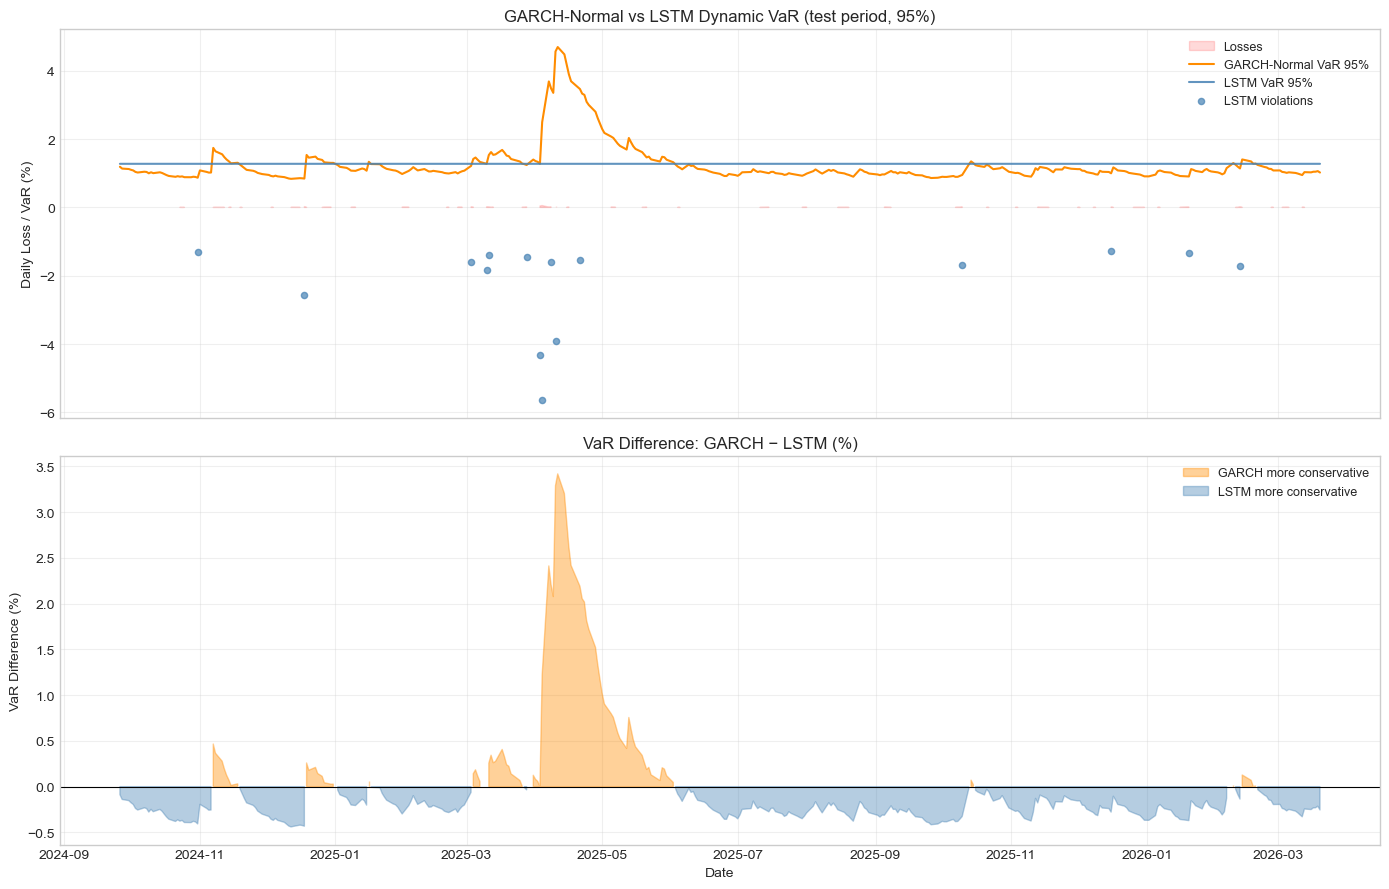

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: VaR series comparison ────────────────────────────────────────────
axes[0].fill_between(shared_idx,
                     -ret_shared.values, 0,
                     where=-ret_shared.values > 0,
                     color="red", alpha=0.15, label="Losses")
axes[0].plot(shared_idx, garch_shared * 100,
             color="darkorange", linewidth=1.5, label="GARCH-Normal VaR 95%")
axes[0].plot(shared_idx, lstm_shared * 100,
             color="steelblue",  linewidth=1.5, label="LSTM VaR 95%",  alpha=0.85)
axes[0].scatter(
    shared_idx[ret_shared.values < -lstm_shared.values],
    (ret_shared[ret_shared < -lstm_shared].values * 100),
    color="steelblue", s=20, zorder=5, label="LSTM violations", alpha=0.7)
axes[0].set_title("GARCH-Normal vs LSTM Dynamic VaR (test period, 95%)")
axes[0].set_ylabel("Daily Loss / VaR (%)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Bottom: difference GARCH - LSTM vol ──────────────────────────────────
diff = (garch_shared - lstm_shared) * 100
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].fill_between(shared_idx, diff, 0,
                     where=diff > 0, alpha=0.4, color="darkorange",
                     label="GARCH more conservative")
axes[1].fill_between(shared_idx, diff, 0,
                     where=diff < 0, alpha=0.4, color="steelblue",
                     label="LSTM more conservative")
axes[1].set_title("VaR Difference: GARCH − LSTM (%)")
axes[1].set_ylabel("VaR Difference (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
# These need to exist before the plot cell runs
# shared_idx  — common date index between GARCH and LSTM test periods
# ret_shared  — portfolio returns aligned to shared_idx
# garch_shared — GARCH VaR series aligned to shared_idx
# lstm_shared  — LSTM VaR series aligned to shared_idx

# Build them like this:
shared_idx   = lstm_vol.index
ret_shared   = port_ret.reindex(shared_idx)
garch_shared = var_garch.reindex(shared_idx)
lstm_shared  = lstm_vol  # already on correct index

print(f"Shared period: {shared_idx[0].date()} → {shared_idx[-1].date()}")
print(f"GARCH VaR range: {garch_shared.min()*100:.3f}% → {garch_shared.max()*100:.3f}%")
print(f"LSTM  VaR range: {lstm_shared.min()*100:.3f}% → {lstm_shared.max()*100:.3f}%")
print(f"Any NaNs — GARCH: {garch_shared.isna().sum()}  LSTM: {lstm_shared.isna().sum()}")

Shared period: 2024-10-14 → 2026-03-20
GARCH VaR range: 0.837% → 4.696%
LSTM  VaR range: 0.284% → 1.006%
Any NaNs — GARCH: 0  LSTM: 0


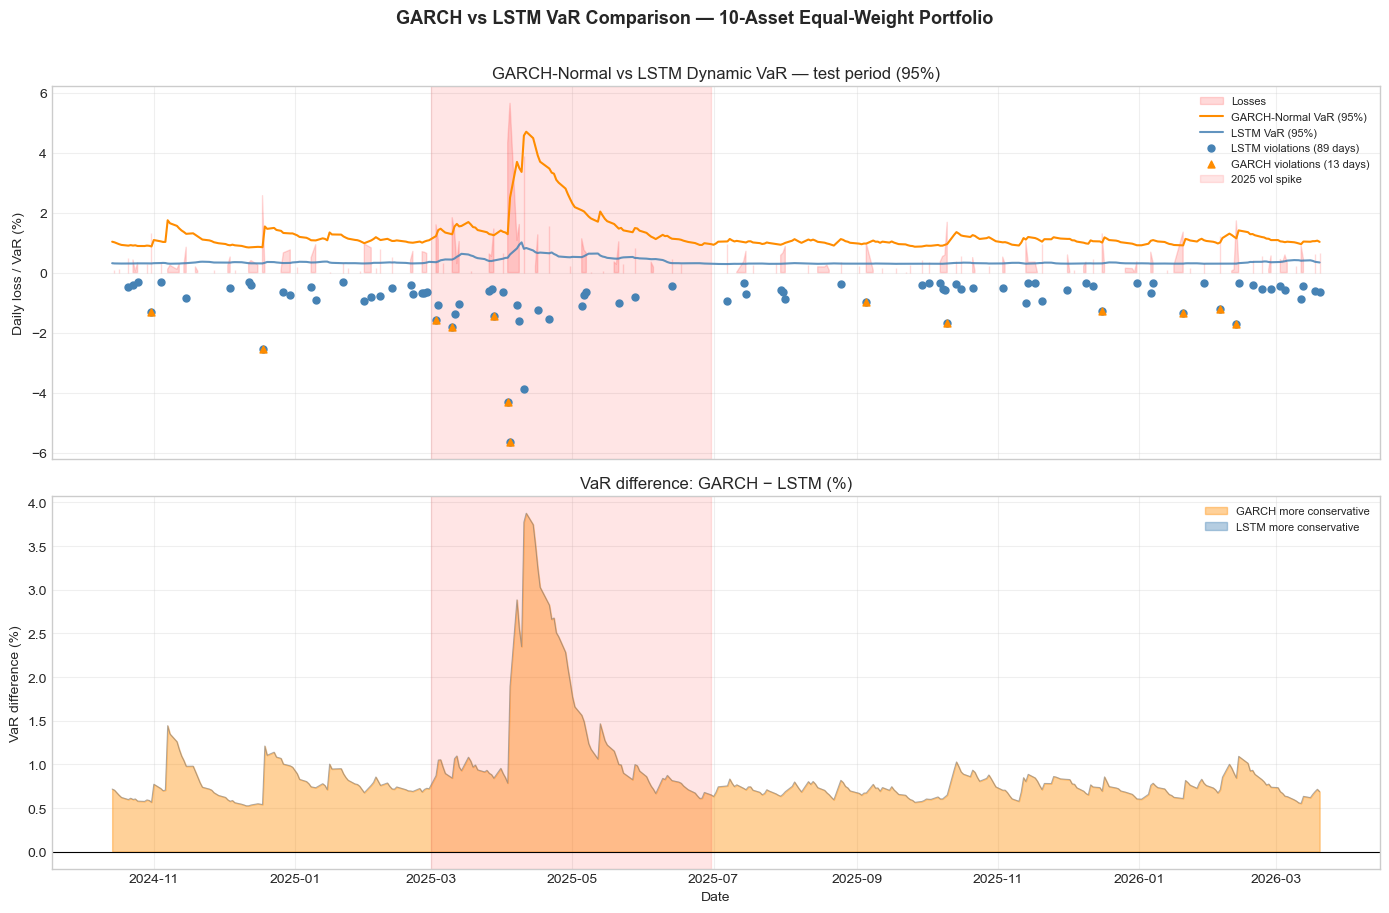

Saved to lstm_vs_garch.png


In [68]:
# Alignment cell — run this first
shared_idx   = lstm_vol.index
ret_shared   = port_ret.reindex(shared_idx)
garch_shared = var_garch.reindex(shared_idx)
lstm_shared  = lstm_vol

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top: VaR series comparison ─────────────────────────────────
axes[0].fill_between(shared_idx,
                     -ret_shared.values * 100, 0,
                     where=-ret_shared.values > 0,
                     color="red", alpha=0.15, label="Losses")

axes[0].plot(shared_idx, garch_shared * 100,
             color="darkorange", linewidth=1.5,
             label="GARCH-Normal VaR (95%)")

axes[0].plot(shared_idx, lstm_shared * 100,
             color="steelblue", linewidth=1.5,
             alpha=0.85, label="LSTM VaR (95%)")

# LSTM violations
lstm_violations = ret_shared < -lstm_shared
axes[0].scatter(
    shared_idx[lstm_violations],
    ret_shared[lstm_violations].values * 100,
    color="steelblue", s=25, zorder=5,
    label=f"LSTM violations ({lstm_violations.sum()} days)")

# GARCH violations
garch_violations = ret_shared < -garch_shared
axes[0].scatter(
    shared_idx[garch_violations],
    ret_shared[garch_violations].values * 100,
    color="darkorange", s=25, zorder=5, marker="^",
    label=f"GARCH violations ({garch_violations.sum()} days)")

# Crisis shading
crises = {
    "2025 vol spike": (pd.Timestamp("2025-03-01"),
                       pd.Timestamp("2025-06-30")),
}
for name, (s, e) in crises.items():
    axes[0].axvspan(s, e, alpha=0.10, color="red", label=name)

axes[0].set_title("GARCH-Normal vs LSTM Dynamic VaR — test period (95%)")
axes[0].set_ylabel("Daily loss / VaR (%)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Bottom: difference GARCH − LSTM ───────────────────────────
diff = (garch_shared - lstm_shared) * 100

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].fill_between(shared_idx, diff, 0,
                     where=diff > 0, alpha=0.4,
                     color="darkorange",
                     label="GARCH more conservative")
axes[1].fill_between(shared_idx, diff, 0,
                     where=diff < 0, alpha=0.4,
                     color="steelblue",
                     label="LSTM more conservative")
axes[1].plot(shared_idx, diff,
             color="gray", linewidth=0.8, alpha=0.6)

for name, (s, e) in crises.items():
    axes[1].axvspan(s, e, alpha=0.10, color="red")

axes[1].set_title("VaR difference: GARCH − LSTM (%)")
axes[1].set_ylabel("VaR difference (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("GARCH vs LSTM VaR Comparison — 10-Asset Equal-Weight Portfolio",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("lstm_vs_garch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to lstm_vs_garch.png")

In [69]:
print(f"{'Method':<20} {'Violations':>10} {'Rate':>8} "
      f"{'Expected':>10} {'p-value':>9} {'Passes':>8}")
print("-" * 70)

for name, var in [("GARCH Normal", garch_shared),
                   ("LSTM",         lstm_shared)]:
    r = kupiec_test_series(ret_shared, var, 0.95)
    print(f"{name:<20} {r['violations']:>10} "
          f"{r['violation_rate']:>8} "
          f"{r['expected_rate']:>10} "
          f"{r['p-value']:>9} "
          f"{r['passes']:>8}")

Method               Violations     Rate   Expected   p-value   Passes
----------------------------------------------------------------------
GARCH Normal                 13    3.62%      5.00%    0.2084      YES
LSTM                         89   24.79%      5.00%       0.0       NO
